I want to compute statistical significance of context_variants for BC detection. But just trying to show with venn-diagram representation.

In [9]:
!pip install matplotlib-venn


GPT-4o:
  Minimal only        : 2
  Method only         : 0
  Class only          : 9
  Minimal & Method    : 0
  Minimal & Class     : 5
  Method  & Class     : 3
  All three           : 10
  None                : 60
  Total BUMP          : 89

Qwen-480B:
  Minimal only        : 3
  Method only         : 4
  Class only          : 4
  Minimal & Method    : 1
  Minimal & Class     : 1
  Method  & Class     : 2
  All three           : 13
  None                : 61
  Total BUMP          : 89

GPT-OSS-120b:
  Minimal only        : 1
  Method only         : 0
  Class only          : 2
  Minimal & Method    : 0
  Minimal & Class     : 0
  Method  & Class     : 5
  All three           : 3
  None                : 78
  Total BUMP          : 89

Saved → /Volumes/Rachna-HD/RQResultsForPaper/RQ2/figures/venn_context_detection.pdf
Saved → /Volumes/Rachna-HD/RQResultsForPaper/RQ2/figures/venn_context_detection.png


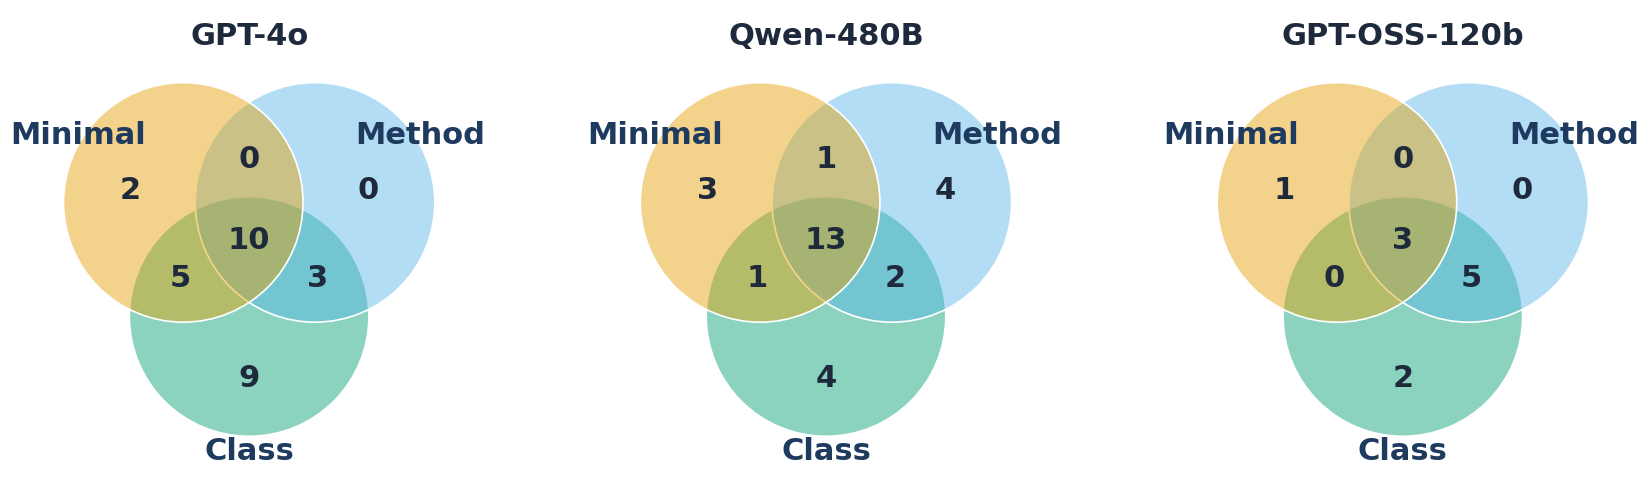

In [10]:
"""
venn_context_detection.py
==========================
Generates one 3-way Venn diagram per model showing which instances
are detected by Minimal, Method, and/or Class context variants.
Uses perfectly equal fixed-size circles with actual counts as labels.
No matplotlib-venn needed.
"""

import math
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba
from pathlib import Path

# ─── CONFIG ───────────────────────────────────────────────────────────────────
DETECTED_CSV = "/Volumes/Rachna-HD/RQResultsForPaper/RQ2/detected_bc_errortype_coverage.csv"
BUMP_CSV     = "/Volumes/Rachna-HD/ConfigFiles/Candidate_BUMP_Instance_errorTypes_with_categories_v2.csv"
OUTPUT_DIR   = "/Volumes/Rachna-HD/RQResultsForPaper/RQ2/figures"

MODEL_ORDER   = ['GPT-4o', 'Qwen-480B', 'GPT-OSS-120b']
VARIANT_ORDER = ['Minimal', 'Method', 'Class']

# Wong colorblind-safe palette
COLORS = {
    'Minimal': '#E69F00',
    'Method':  '#56B4E9',
    'Class':   '#009E73',
}
# ──────────────────────────────────────────────────────────────────────────────

# ── Geometry ──────────────────────────────────────────────────────────────────
RADIUS = 0.40
OFFSET = 0.22

CENTERS = {
    'Minimal': (-OFFSET,  OFFSET * math.tan(math.radians(30))),
    'Method':  (+OFFSET,  OFFSET * math.tan(math.radians(30))),
    'Class':   ( 0.0,    -OFFSET / math.cos(math.radians(30))),
}

_s = OFFSET * 0.95
REGION_POS = {
    '100': (-_s * 1.9,  _s * 0.8),
    '010': (+_s * 1.9,  _s * 0.8),
    '001': ( 0.0,      -_s * 2.2),
    '110': ( 0.0,       _s * 1.3),
    '101': (-_s * 1.1, -_s * 0.6),
    '011': (+_s * 1.1, -_s * 0.6),
    '111': ( 0.0,       0.0),
}

SET_LABEL_POS = {
    'Minimal': (-OFFSET * 2.6,  OFFSET * 1.6),
    'Method':  (+OFFSET * 2.6,  OFFSET * 1.6),
    'Class':   ( 0.0,          -OFFSET * 3.2),
}
# ─────────────────────────────────────────────────────────────────────────────


def load_data(detected_csv, bump_csv):
    df = pd.read_csv(detected_csv, sep=None, engine='python',
                     dtype=str, keep_default_na=False)
    df['custom_id']       = df['custom_id'].str.strip()
    df['model']           = df['model'].str.strip()
    df['context_variant'] = df['context_variant'].str.strip()

    bump_df = pd.read_csv(bump_csv, sep=None, engine='python',
                          dtype=str, keep_default_na=False)
    all_ids = set(bump_df['custom_id'].str.strip().unique())
    return df, all_ids


def get_detected_sets(df, model):
    mdf = df[df['model'] == model]
    return {v: set(mdf[mdf['context_variant'] == v]['custom_id'].unique())
            for v in VARIANT_ORDER}


def plot_venn(model, sets, all_ids, ax):
    A, B, C = sets['Minimal'], sets['Method'], sets['Class']

    only_A  = A - B - C
    only_B  = B - A - C
    only_C  = C - A - B
    AB_only = (A & B) - C
    AC_only = (A & C) - B
    BC_only = (B & C) - A
    ABC     = A & B & C
    none    = all_ids - A - B - C

    region_counts = {
        '100': len(only_A),
        '010': len(only_B),
        '001': len(only_C),
        '110': len(AB_only),
        '101': len(AC_only),
        '011': len(BC_only),
        '111': len(ABC),
    }

    # ── Draw filled circles (back → front) ───────────────────────────────
    for variant in ['Class', 'Method', 'Minimal']:
        cx, cy = CENTERS[variant]
        ax.add_patch(mpatches.Circle(
            (cx, cy), RADIUS,
            facecolor=to_rgba(COLORS[variant], alpha=0.45),
            edgecolor='white',
            linewidth=1.2,
            zorder=2,
        ))

    # ── Region count labels ───────────────────────────────────────────────
    for rid, (rx, ry) in REGION_POS.items():
        ax.text(rx, ry, str(region_counts[rid]),
                ha='center', va='center',
                fontsize=22, fontweight='bold', color='#1e293b',
                zorder=3)

    # ── Set name labels ───────────────────────────────────────────────────
    for variant, (lx, ly) in SET_LABEL_POS.items():
        ax.text(lx, ly, variant,
                ha='center', va='center',
                fontsize=22, fontweight='bold', color='#1e3a5f',
                zorder=3)

    # ── Axes limits (must be set before ax.text using lim) ───────────────
    lim = RADIUS + OFFSET + 0.15
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect('equal')
    ax.axis('off')

    # ── Model name inside top of axes ────────────────────────────────────
    ax.text(0, lim - 0.04, model,
            ha='center', va='top',
            fontsize=22, fontweight='bold', color='#1e293b',
            zorder=4)

    # Console breakdown
    print(f"\n{model}:")
    print(f"  Minimal only        : {len(only_A)}")
    print(f"  Method only         : {len(only_B)}")
    print(f"  Class only          : {len(only_C)}")
    print(f"  Minimal & Method    : {len(AB_only)}")
    print(f"  Minimal & Class     : {len(AC_only)}")
    print(f"  Method  & Class     : {len(BC_only)}")
    print(f"  All three           : {len(ABC)}")
    print(f"  None                : {len(none)}")
    print(f"  Total BUMP          : {len(all_ids)}")


def main():
    out_dir = Path(OUTPUT_DIR)
    out_dir.mkdir(parents=True, exist_ok=True)

    df, all_ids = load_data(DETECTED_CSV, BUMP_CSV)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for ax, model in zip(axes, MODEL_ORDER):
        sets = get_detected_sets(df, model)
        plot_venn(model, sets, all_ids, ax)

    plt.tight_layout(pad=2.5)

    out_pdf = out_dir / "venn_context_detection.pdf"
    out_png = out_dir / "venn_context_detection.png"
    fig.savefig(out_pdf, bbox_inches='tight', dpi=300)
    fig.savefig(out_png, bbox_inches='tight', dpi=300)
    print(f"\nSaved → {out_pdf}")
    print(f"Saved → {out_png}")
    plt.show()


if __name__ == "__main__":
    main()


GPT-4o:
  Minimal only        : 2
  Method only         : 0
  Class only          : 9
  Minimal & Method    : 0
  Minimal & Class     : 5
  Method  & Class     : 3
  All three           : 10
  None                : 60
  Total BUMP          : 89

Qwen-480B:
  Minimal only        : 3
  Method only         : 4
  Class only          : 4
  Minimal & Method    : 1
  Minimal & Class     : 1
  Method  & Class     : 2
  All three           : 13
  None                : 61
  Total BUMP          : 89

GPT-OSS-120b:
  Minimal only        : 1
  Method only         : 0
  Class only          : 2
  Minimal & Method    : 0
  Minimal & Class     : 0
  Method  & Class     : 5
  All three           : 3
  None                : 78
  Total BUMP          : 89

Saved → /Volumes/Rachna-HD/RQResultsForPaper/RQ2/figures/venn_context_detection.pdf
Saved → /Volumes/Rachna-HD/RQResultsForPaper/RQ2/figures/venn_context_detection.png


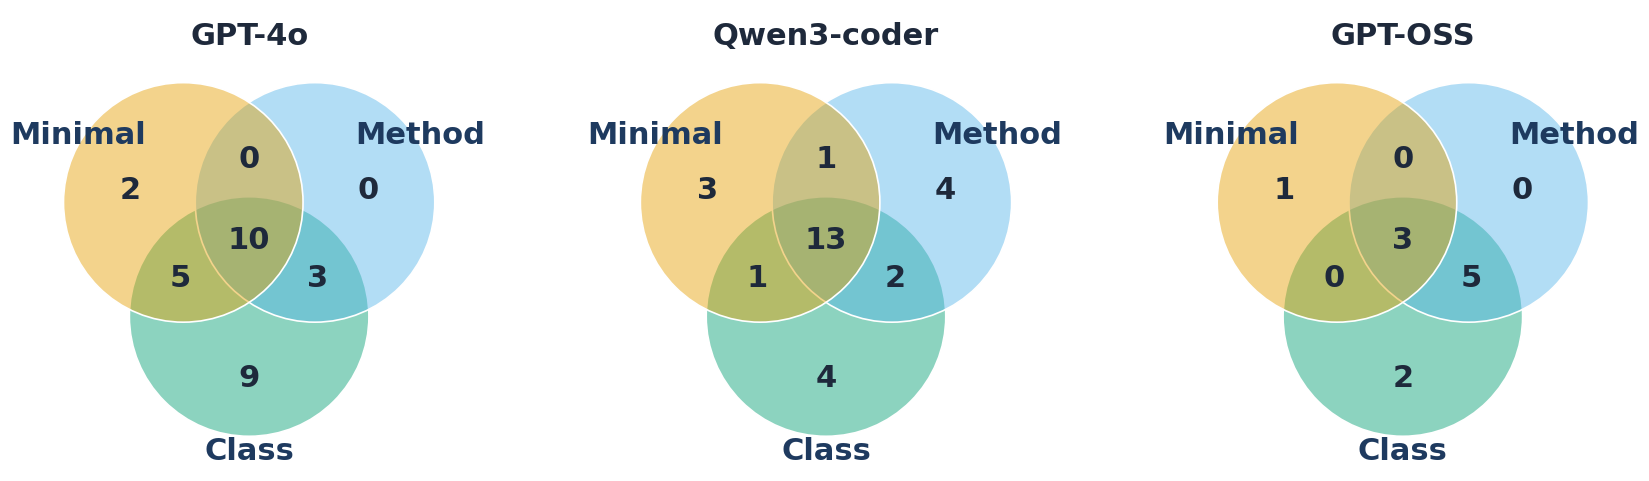

In [11]:
"""
venn_context_detection.py
==========================
Generates one 3-way Venn diagram per model showing which instances
are detected by Minimal, Method, and/or Class context variants.
Uses perfectly equal fixed-size circles with actual counts as labels.
No matplotlib-venn needed.
"""

import math
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba
from pathlib import Path

# ─── CONFIG ───────────────────────────────────────────────────────────────────
DETECTED_CSV = "/Volumes/Rachna-HD/RQResultsForPaper/RQ2/detected_bc_errortype_coverage.csv"
BUMP_CSV     = "/Volumes/Rachna-HD/ConfigFiles/Candidate_BUMP_Instance_errorTypes_with_categories_v2.csv"
OUTPUT_DIR   = "/Volumes/Rachna-HD/RQResultsForPaper/RQ2/figures"

MODEL_ORDER   = ['GPT-4o', 'Qwen-480B', 'GPT-OSS-120b']
VARIANT_ORDER = ['Minimal', 'Method', 'Class']

# Names as they appear in the CSV  →  names to display on the plot
DISPLAY_NAMES = {
    'GPT-4o':       'GPT-4o',
    'Qwen-480B':    'Qwen3-coder',
    'GPT-OSS-120b': 'GPT-OSS',
}

# Wong colorblind-safe palette
COLORS = {
    'Minimal': '#E69F00',
    'Method':  '#56B4E9',
    'Class':   '#009E73',
}
# ──────────────────────────────────────────────────────────────────────────────

# ── Geometry ──────────────────────────────────────────────────────────────────
RADIUS = 0.40
OFFSET = 0.22

CENTERS = {
    'Minimal': (-OFFSET,  OFFSET * math.tan(math.radians(30))),
    'Method':  (+OFFSET,  OFFSET * math.tan(math.radians(30))),
    'Class':   ( 0.0,    -OFFSET / math.cos(math.radians(30))),
}

_s = OFFSET * 0.95
REGION_POS = {
    '100': (-_s * 1.9,  _s * 0.8),
    '010': (+_s * 1.9,  _s * 0.8),
    '001': ( 0.0,      -_s * 2.2),
    '110': ( 0.0,       _s * 1.3),
    '101': (-_s * 1.1, -_s * 0.6),
    '011': (+_s * 1.1, -_s * 0.6),
    '111': ( 0.0,       0.0),
}

SET_LABEL_POS = {
    'Minimal': (-OFFSET * 2.6,  OFFSET * 1.6),
    'Method':  (+OFFSET * 2.6,  OFFSET * 1.6),
    'Class':   ( 0.0,          -OFFSET * 3.2),
}
# ─────────────────────────────────────────────────────────────────────────────


def load_data(detected_csv, bump_csv):
    df = pd.read_csv(detected_csv, sep=None, engine='python',
                     dtype=str, keep_default_na=False)
    df['custom_id']       = df['custom_id'].str.strip()
    df['model']           = df['model'].str.strip()
    df['context_variant'] = df['context_variant'].str.strip()

    bump_df = pd.read_csv(bump_csv, sep=None, engine='python',
                          dtype=str, keep_default_na=False)
    all_ids = set(bump_df['custom_id'].str.strip().unique())
    return df, all_ids


def get_detected_sets(df, model):
    mdf = df[df['model'] == model]
    return {v: set(mdf[mdf['context_variant'] == v]['custom_id'].unique())
            for v in VARIANT_ORDER}


def plot_venn(model, sets, all_ids, ax):
    A, B, C = sets['Minimal'], sets['Method'], sets['Class']

    only_A  = A - B - C
    only_B  = B - A - C
    only_C  = C - A - B
    AB_only = (A & B) - C
    AC_only = (A & C) - B
    BC_only = (B & C) - A
    ABC     = A & B & C
    none    = all_ids - A - B - C

    region_counts = {
        '100': len(only_A),
        '010': len(only_B),
        '001': len(only_C),
        '110': len(AB_only),
        '101': len(AC_only),
        '011': len(BC_only),
        '111': len(ABC),
    }

    # ── Draw filled circles (back → front) ───────────────────────────────
    for variant in ['Class', 'Method', 'Minimal']:
        cx, cy = CENTERS[variant]
        ax.add_patch(mpatches.Circle(
            (cx, cy), RADIUS,
            facecolor=to_rgba(COLORS[variant], alpha=0.45),
            edgecolor='white',
            linewidth=1.2,
            zorder=2,
        ))

    # ── Region count labels ───────────────────────────────────────────────
    for rid, (rx, ry) in REGION_POS.items():
        ax.text(rx, ry, str(region_counts[rid]),
                ha='center', va='center',
                fontsize=22, fontweight='bold', color='#1e293b',
                zorder=3)

    # ── Set name labels ───────────────────────────────────────────────────
    for variant, (lx, ly) in SET_LABEL_POS.items():
        ax.text(lx, ly, variant,
                ha='center', va='center',
                fontsize=22, fontweight='bold', color='#1e3a5f',
                zorder=3)

    # ── Axes limits (must be set before ax.text using lim) ───────────────
    lim = RADIUS + OFFSET + 0.15
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect('equal')
    ax.axis('off')

    # ── Model name inside top of axes (use display name only here) ───────
    ax.text(0, lim - 0.04, DISPLAY_NAMES.get(model, model),
            ha='center', va='top',
            fontsize=22, fontweight='bold', color='#1e293b',
            zorder=4)

    # Console breakdown (uses CSV name for clarity when debugging)
    print(f"\n{model}:")
    print(f"  Minimal only        : {len(only_A)}")
    print(f"  Method only         : {len(only_B)}")
    print(f"  Class only          : {len(only_C)}")
    print(f"  Minimal & Method    : {len(AB_only)}")
    print(f"  Minimal & Class     : {len(AC_only)}")
    print(f"  Method  & Class     : {len(BC_only)}")
    print(f"  All three           : {len(ABC)}")
    print(f"  None                : {len(none)}")
    print(f"  Total BUMP          : {len(all_ids)}")


def main():
    out_dir = Path(OUTPUT_DIR)
    out_dir.mkdir(parents=True, exist_ok=True)

    df, all_ids = load_data(DETECTED_CSV, BUMP_CSV)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for ax, model in zip(axes, MODEL_ORDER):
        sets = get_detected_sets(df, model)
        plot_venn(model, sets, all_ids, ax)

    plt.tight_layout(pad=2.5)

    out_pdf = out_dir / "venn_context_detection.pdf"
    out_png = out_dir / "venn_context_detection.png"
    fig.savefig(out_pdf, bbox_inches='tight', dpi=300)
    fig.savefig(out_png, bbox_inches='tight', dpi=300)
    print(f"\nSaved → {out_pdf}")
    print(f"Saved → {out_png}")
    plt.show()


if __name__ == "__main__":
    main()

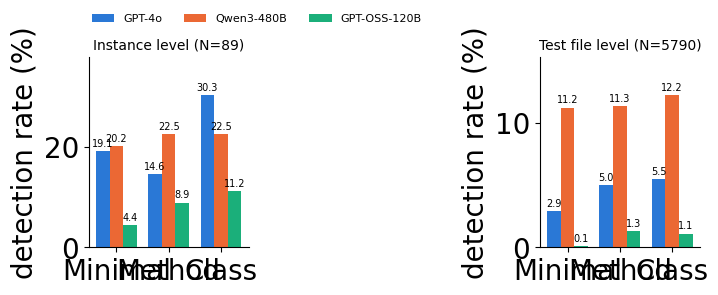

In [12]:
import matplotlib.pyplot as plt
import numpy as np

contexts = ["Minimal", "Method", "Class"]
models = ["GPT-4o", "Qwen3-480B", "GPT-OSS-120B"]
# detection rate (%) per level, rows = models, cols = contexts
rates = {
    "Instance level (N=89)":    [[19.1, 14.6, 30.3], [20.2, 22.5, 22.5], [4.4, 8.9, 11.2]],
    "Test file level (N=5790)": [[2.9, 5.0, 5.5],    [11.2, 11.3, 12.2], [0.1, 1.3, 1.1]],
}
colors = ["#2a78d6", "#eb6834", "#1baf7a"]   # Cove order, one per model
x = np.arange(len(contexts)); w = 0.26

fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.6))
for ax, (title, mat) in zip(axes, rates.items()):
    for i, (m, c) in enumerate(zip(models, colors)):
        bars = ax.bar(x + (i - 1) * w, mat[i], w, color=c, label=m)
        ax.bar_label(bars, fmt="%.1f", fontsize=7, padding=2)
    ax.set_title(title, fontsize=10)
    ax.set_xticks(x); ax.set_xticklabels(contexts)
    ax.set_ylabel("detection rate (%)")
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_ylim(0, max(max(r) for r in mat) * 1.25)

axes[0].legend(frameon=False, fontsize=8, ncol=3,
               loc="upper center", bbox_to_anchor=(1.05, 1.28))
plt.tight_layout(); plt.savefig("rq2_grouped_bars.pdf", bbox_inches="tight")

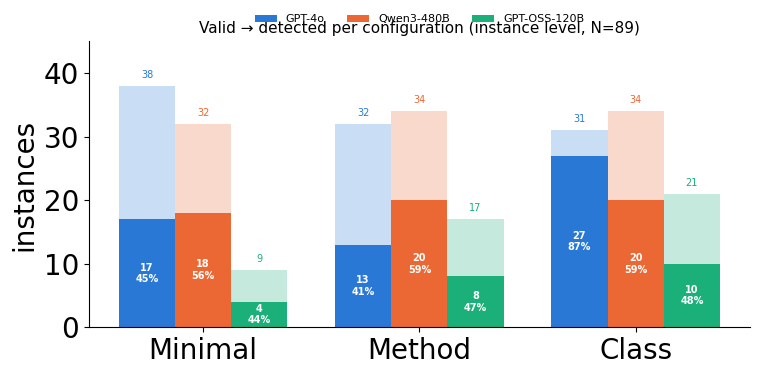

In [13]:
import matplotlib.pyplot as plt
import numpy as np

contexts = ["Minimal", "Method", "Class"]
models = ["GPT-4o", "Qwen3-480B", "GPT-OSS-120B"]
N = 89
# (valid, detected) per model x context
valid = {"GPT-4o":[38,32,31], "Qwen3-480B":[32,34,34], "GPT-OSS-120B":[9,17,21]}
det   = {"GPT-4o":[17,13,27], "Qwen3-480B":[18,20,20], "GPT-OSS-120B":[4,8,10]}
colors = ["#2a78d6", "#eb6834", "#1baf7a"]
x = np.arange(len(contexts)); w = 0.26

fig, ax = plt.subplots(figsize=(8, 4.2))
for i, (m, c) in enumerate(zip(models, colors)):
    xpos = x + (i-1)*w
    v, d = np.array(valid[m]), np.array(det[m])
    # pale bar = valid (survived pre-breaking), solid = detected (survived breaking)
    ax.bar(xpos, v, w, color=c, alpha=0.25)
    bars = ax.bar(xpos, d, w, color=c, label=m)
    for xp, dv, vv in zip(xpos, d, v):
        ax.text(xp, dv/2, f"{dv}\n{dv/vv*100:.0f}%", ha="center", va="center",
                fontsize=7, color="white", fontweight="bold")   # detected count + yield inside
        ax.text(xp, vv+1, f"{vv}", ha="center", va="bottom",
                fontsize=7, color=c)                              # valid count above pale bar

ax.set_xticks(x); ax.set_xticklabels(contexts)
ax.set_ylabel("instances"); ax.set_ylim(0, 45)
ax.set_title("Valid \u2192 detected per configuration (instance level, N=89)", fontsize=11)
ax.spines[["top","right"]].set_visible(False)
ax.legend(frameon=False, fontsize=8, ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.13))
plt.tight_layout(); plt.savefig("rq2_funnel.pdf", bbox_inches="tight")

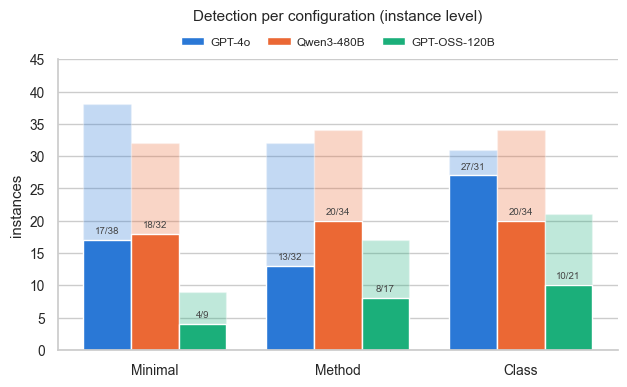

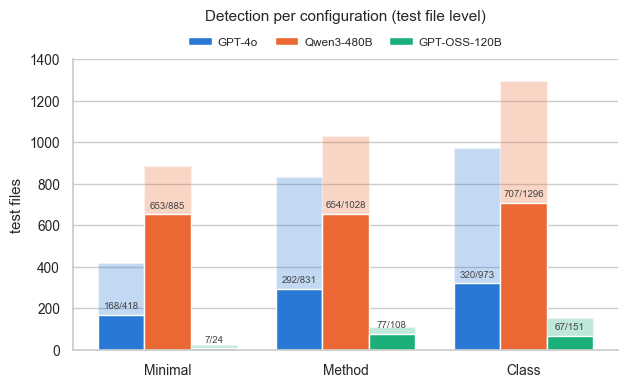

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=0.9)

models   = ["GPT-4o", "Qwen3-480B", "GPT-OSS-120B"]
colors   = {"GPT-4o": "#2a78d6", "Qwen3-480B": "#eb6834", "GPT-OSS-120B": "#1baf7a"}
contexts = ["Minimal", "Method", "Class"]

def grouped(valid, det, fname, title, ylabel, ymax):
    x = np.arange(len(contexts)); w = 0.26
    fig, ax = plt.subplots(figsize=(6.4, 4.0))
    for i, m in enumerate(models):
        xp = x + (i - 1) * w
        v = [valid[m][j] for j in range(3)]
        d = [det[m][j]   for j in range(3)]
        ax.bar(xp, v, w, color=colors[m], alpha=0.28)          # valid (pale)
        ax.bar(xp, d, w, color=colors[m], label=m)             # detected (dark)
        for xx, dd, vv in zip(xp, d, v):
            ax.text(xx, dd + ymax*0.015, f"{dd}/{vv}",
                    ha="center", va="bottom", fontsize=7, color="#444")

    ax.set_xticks(x); ax.set_xticklabels(contexts)
    ax.set_ylabel(ylabel); ax.set_ylim(0, ymax)
    ax.set_title(title, fontsize=11, pad=28)
    ax.grid(axis="x", visible=False)          # no vertical lines
    sns.despine()
    ax.legend(frameon=False, fontsize=8.5, ncol=3,
              loc="lower center", bbox_to_anchor=(0.5, 1.005),
              handletextpad=0.5, columnspacing=1.4)
    plt.tight_layout(); plt.savefig(fname, bbox_inches="tight")

# instance level
grouped({"GPT-4o":[38,32,31], "Qwen3-480B":[32,34,34], "GPT-OSS-120B":[9,17,21]},
        {"GPT-4o":[17,13,27], "Qwen3-480B":[18,20,20], "GPT-OSS-120B":[4,8,10]},
        "rq2_instance.pdf", "Detection per configuration (instance level)",
        "instances", 45)

# test file level  (y-max scaled to valid counts, not 5790)
grouped({"GPT-4o":[418,831,973], "Qwen3-480B":[885,1028,1296], "GPT-OSS-120B":[24,108,151]},
        {"GPT-4o":[168,292,320], "Qwen3-480B":[653,654,707],   "GPT-OSS-120B":[7,77,67]},
        "rq2_file.pdf", "Detection per configuration (test file level)",
        "test files", 1400)

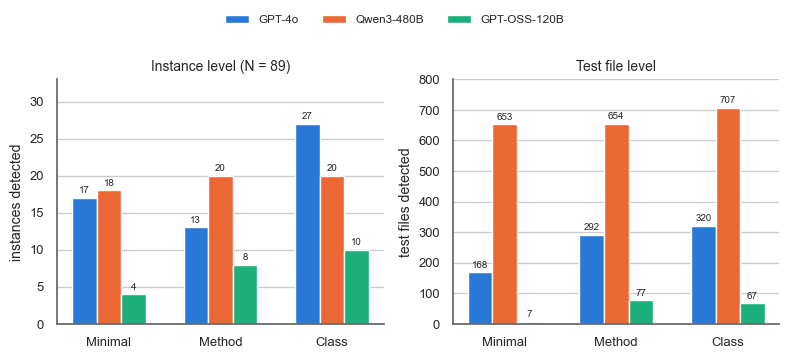

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=0.85)
plt.rcParams["axes.edgecolor"] = "#666"

models   = ["GPT-4o", "Qwen3-480B", "GPT-OSS-120B"]
colors   = {"GPT-4o": "#2a78d6", "Qwen3-480B": "#eb6834", "GPT-OSS-120B": "#1baf7a"}
contexts = ["Minimal", "Method", "Class"]

det_inst = {"GPT-4o":[17,13,27], "Qwen3-480B":[18,20,20], "GPT-OSS-120B":[4,8,10]}
det_file = {"GPT-4o":[168,292,320], "Qwen3-480B":[653,654,707], "GPT-OSS-120B":[7,77,67]}

fig, axes = plt.subplots(1, 2, figsize=(8, 3.4))
x = np.arange(len(contexts)); w = 0.22

def panel(ax, data, title, ylabel, ymax):
    for i, m in enumerate(models):
        xp = x + (i - 1) * w
        bars = ax.bar(xp, data[m], w, color=colors[m], label=m)
        ax.bar_label(bars, fontsize=7, padding=2)
    ax.set_xticks(x); ax.set_xticklabels(contexts)
    ax.set_ylabel(ylabel); ax.set_ylim(0, ymax)
    ax.set_title(title, fontsize=10)
    ax.grid(axis="x", visible=False)
    sns.despine(ax=ax)

panel(axes[0], det_inst, "Instance level (N = 89)", "instances detected", 33)
panel(axes[1], det_file, "Test file level",          "test files detected", 800)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, fontsize=8.5, ncol=3,
           loc="upper center", bbox_to_anchor=(0.5, 1.06))
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("rq2_detection.pdf", bbox_inches="tight")

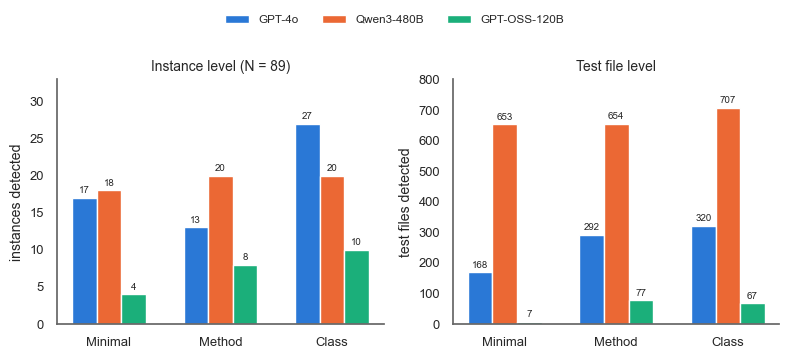

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=0.85)
plt.rcParams["axes.edgecolor"] = "#666"

models   = ["GPT-4o", "Qwen3-480B", "GPT-OSS-120B"]
colors   = {"GPT-4o": "#2a78d6", "Qwen3-480B": "#eb6834", "GPT-OSS-120B": "#1baf7a"}
contexts = ["Minimal", "Method", "Class"]

det_inst = {"GPT-4o":[17,13,27], "Qwen3-480B":[18,20,20], "GPT-OSS-120B":[4,8,10]}
det_file = {"GPT-4o":[168,292,320], "Qwen3-480B":[653,654,707], "GPT-OSS-120B":[7,77,67]}

fig, axes = plt.subplots(1, 2, figsize=(8, 3.4))
x = np.arange(len(contexts)); w = 0.22

def panel(ax, data, title, ylabel, ymax):
    for i, m in enumerate(models):
        xp = x + (i - 1) * w
        bars = ax.bar(xp, data[m], w, color=colors[m], label=m)
        ax.bar_label(bars, fontsize=7, padding=2)
    ax.set_xticks(x); ax.set_xticklabels(contexts)
    ax.set_ylabel(ylabel); ax.set_ylim(0, ymax)
    ax.set_title(title, fontsize=10)
    ax.grid(False)                    # remove all gridlines
    sns.despine(ax=ax)

panel(axes[0], det_inst, "Instance level (N = 89)", "instances detected", 33)
panel(axes[1], det_file, "Test file level",          "test files detected", 800)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, fontsize=8.5, ncol=3,
           loc="upper center", bbox_to_anchor=(0.5, 1.06))
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("rq2_detection.pdf", bbox_inches="tight")

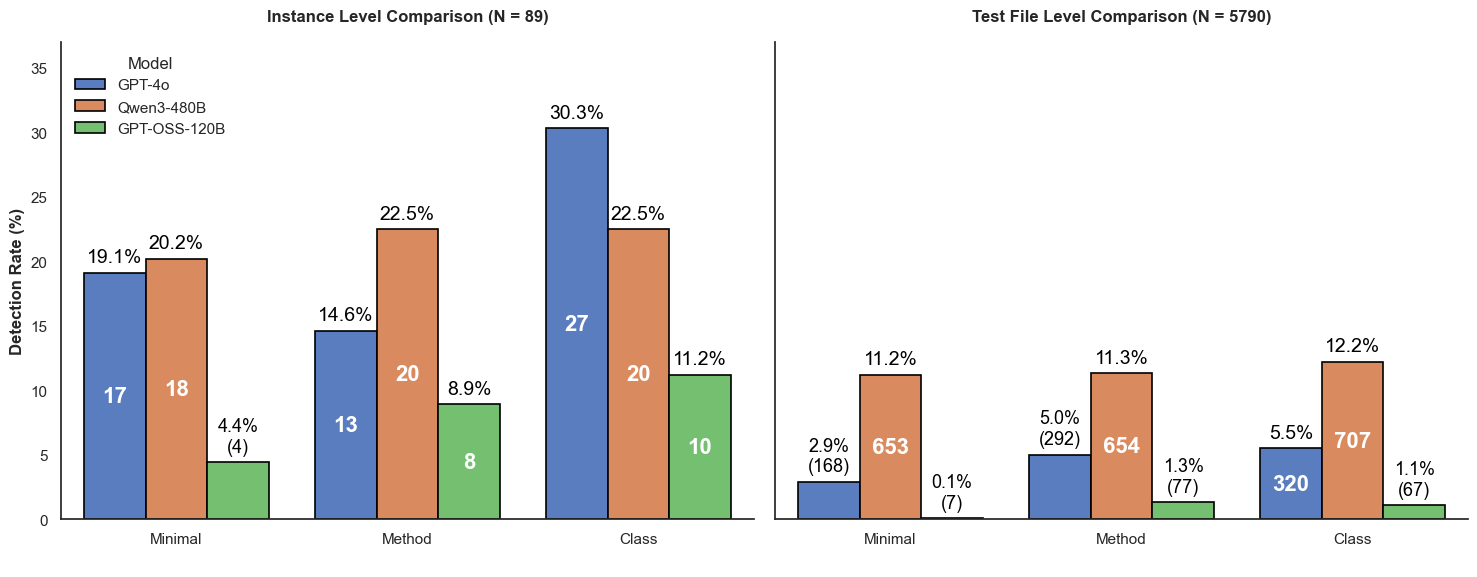

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Prepare the Data 
data = {
    'Model': [
        'GPT-4o', 'GPT-4o', 'GPT-4o',
        'Qwen3-480B', 'Qwen3-480B', 'Qwen3-480B',
        'GPT-OSS-120B', 'GPT-OSS-120B', 'GPT-OSS-120B'
    ],
    'Context': [
        'Minimal', 'Method', 'Class',
        'Minimal', 'Method', 'Class',
        'Minimal', 'Method', 'Class'
    ],
    # Detection Rates (%)
    'Instance_Det_Rate': [19.1, 14.6, 30.3, 20.2, 22.5, 22.5, 4.4, 8.9, 11.2],
    'TestFile_Det_Rate': [2.9, 5.0, 5.5, 11.2, 11.3, 12.2, 0.1, 1.3, 1.1],
    # Raw Detected Counts (#)
    'Instance_Count': [17, 13, 27, 18, 20, 20, 4, 8, 10],
    'TestFile_Count': [168, 292, 320, 653, 654, 707, 7, 77, 67]
}

df = pd.DataFrame(data)

# 2. Set up the plotting style
# Changed to "white" to remove horizontal gridlines
sns.set_theme(style="white")
plt.rcParams.update({'font.size': 14, 'pdf.fonttype': 42})

# Create a figure with 2 side-by-side subplots sharing the same Y-axis
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# ---------------------------------------------------
# Left Panel: Instance Level (N = 89)
# ---------------------------------------------------
sns.barplot(
    data=df, x='Context', y='Instance_Det_Rate', hue='Model', 
    ax=axes[0], palette='muted', edgecolor='black', linewidth=1.2
)

axes[0].set_title('Instance Level Comparison (N = 89)', fontweight='bold', pad=15)
axes[0].set_xlabel('', fontweight='bold')
axes[0].set_ylabel('Detection Rate (%)', fontweight='bold')
# Increased y-limit slightly to give room for the top text
axes[0].set_ylim(0, 37) 

# Add Labels: Slice patches to strictly match DataFrame length
for i, p in enumerate(axes[0].patches[:len(df)]):
    height = p.get_height()
    count = df['Instance_Count'].iloc[i]
    
    if height > 0:
        if height > 5.0:
            # Percentage on top
            axes[0].text(p.get_x() + p.get_width()/2., height + 0.5, 
                         f'{height:.1f}%', ha='center', va='bottom', color='black', fontsize=14)
            # Raw Count inside
            axes[0].text(p.get_x() + p.get_width()/2., height / 2, 
                         f'{count}', ha='center', va='center', color='white', fontweight='bold', fontsize=16)
        else:
            # Stacked neatly above if the bar is too short
            axes[0].text(p.get_x() + p.get_width()/2., height + 0.5, 
                         f'{height:.1f}%\n({count})', ha='center', va='bottom', color='black', fontsize=13)

# ---------------------------------------------------
# Right Panel: Test File Level (N = 5790)
# ---------------------------------------------------
sns.barplot(
    data=df, x='Context', y='TestFile_Det_Rate', hue='Model', 
    ax=axes[1], palette='muted', edgecolor='black', linewidth=1.2
)

axes[1].set_title('Test File Level Comparison (N = 5790)', fontweight='bold', pad=15)
axes[1].set_xlabel(' ', fontweight='bold')
axes[1].set_ylabel('') # Clear y-label since it is shared

# Add Labels: Slice patches to strictly match DataFrame length
for i, p in enumerate(axes[1].patches[:len(df)]):
    height = p.get_height()
    count = df['TestFile_Count'].iloc[i]
    
    if height > 0:
        if height > 5.0:
            # Percentage on top
            axes[1].text(p.get_x() + p.get_width()/2., height + 0.5, 
                         f'{height:.1f}%', ha='center', va='bottom', color='black', fontsize=14)
            # Raw Count inside
            axes[1].text(p.get_x() + p.get_width()/2., height / 2, 
                         f'{count}', ha='center', va='center', color='white', fontweight='bold', fontsize=16)
        else:
            # Stacked neatly above if the bar is too short
            axes[1].text(p.get_x() + p.get_width()/2., height + 0.5, 
                         f'{height:.1f}%\n({count})', ha='center', va='bottom', color='black', fontsize=13)

# ---------------------------------------------------
# Final Layout Adjustments
# ---------------------------------------------------
axes[0].legend(title='Model', loc='upper left', frameon=False)
axes[1].get_legend().remove()

# Removes the top and right chart borders for a cleaner, modern look
sns.despine()

plt.tight_layout()
plt.show()

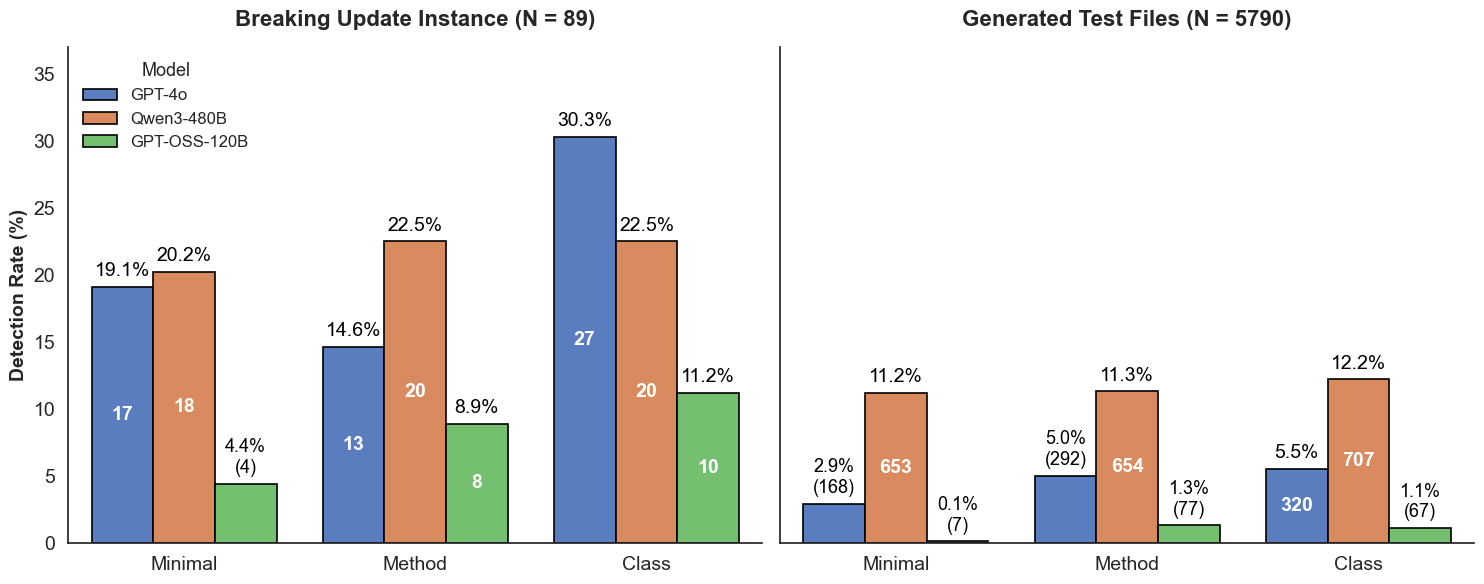

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Prepare the Data 
data = {
    'Model': [
        'GPT-4o', 'GPT-4o', 'GPT-4o',
        'Qwen3-480B', 'Qwen3-480B', 'Qwen3-480B',
        'GPT-OSS-120B', 'GPT-OSS-120B', 'GPT-OSS-120B'
    ],
    'Context': [
        'Minimal', 'Method', 'Class',
        'Minimal', 'Method', 'Class',
        'Minimal', 'Method', 'Class'
    ],
    # Detection Rates (%)
    'Instance_Det_Rate': [19.1, 14.6, 30.3, 20.2, 22.5, 22.5, 4.4, 8.9, 11.2],
    'TestFile_Det_Rate': [2.9, 5.0, 5.5, 11.2, 11.3, 12.2, 0.1, 1.3, 1.1],
    # Raw Detected Counts (#)
    'Instance_Count': [17, 13, 27, 18, 20, 20, 4, 8, 10],
    'TestFile_Count': [168, 292, 320, 653, 654, 707, 7, 77, 67]
}

df = pd.DataFrame(data)

# 2. Set up the plotting style
# Changed to "white" to remove horizontal gridlines
sns.set_theme(style="white")
plt.rcParams.update({'font.size': 12, 'pdf.fonttype': 42})

# Create a figure with 2 side-by-side subplots sharing the same Y-axis
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# ---------------------------------------------------
# Left Panel: Instance Level (N = 89)
# ---------------------------------------------------
sns.barplot(
    data=df, x='Context', y='Instance_Det_Rate', hue='Model', 
    ax=axes[0], palette='muted', edgecolor='black', linewidth=1.2
)

axes[0].set_title('Breaking Update Instance (N = 89)', fontweight='bold', pad=15, fontsize=16)
axes[0].set_xlabel('', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Detection Rate (%)', fontweight='bold', fontsize=14)
axes[0].set_ylim(0, 37) 

# Increase font size for axis tick labels (Minimal, Method, Class, and Y-axis numbers)
axes[0].tick_params(axis='both', labelsize=14)

# Add Labels: Slice patches to strictly match DataFrame length
for i, p in enumerate(axes[0].patches[:len(df)]):
    height = p.get_height()
    count = df['Instance_Count'].iloc[i]
    
    if height > 0:
        if height > 5.0:
            # Percentage on top
            axes[0].text(p.get_x() + p.get_width()/2., height + 0.5, 
                         f'{height:.1f}%', ha='center', va='bottom', color='black', fontsize=14)
            # Raw Count inside
            axes[0].text(p.get_x() + p.get_width()/2., height / 2, 
                         f'{count}', ha='center', va='center', color='white', fontweight='bold', fontsize=14)
        else:
            # Stacked neatly above if the bar is too short
            axes[0].text(p.get_x() + p.get_width()/2., height + 0.5, 
                         f'{height:.1f}%\n({count})', ha='center', va='bottom', color='black', fontsize=13)

# ---------------------------------------------------
# Right Panel: Test File Level (N = 5790)
# ---------------------------------------------------
sns.barplot(
    data=df, x='Context', y='TestFile_Det_Rate', hue='Model', 
    ax=axes[1], palette='muted', edgecolor='black', linewidth=1.2
)

axes[1].set_title('Generated Test Files (N = 5790)', fontweight='bold', pad=15, fontsize=16)
axes[1].set_xlabel('', fontweight='bold', fontsize=14)
axes[1].set_ylabel('') # Clear y-label since it is shared

# Increase font size for axis tick labels
axes[1].tick_params(axis='both', labelsize=14)

# Add Labels: Slice patches to strictly match DataFrame length
for i, p in enumerate(axes[1].patches[:len(df)]):
    height = p.get_height()
    count = df['TestFile_Count'].iloc[i]
    
    if height > 0:
        if height > 5.0:
            # Percentage on top
            axes[1].text(p.get_x() + p.get_width()/2., height + 0.5, 
                         f'{height:.1f}%', ha='center', va='bottom', color='black', fontsize=14)
            # Raw Count inside
            axes[1].text(p.get_x() + p.get_width()/2., height / 2, 
                         f'{count}', ha='center', va='center', color='white', fontweight='bold', fontsize=14)
        else:
            # Stacked neatly above if the bar is too short
            axes[1].text(p.get_x() + p.get_width()/2., height + 0.5, 
                         f'{height:.1f}%\n({count})', ha='center', va='bottom', color='black', fontsize=13)

# ---------------------------------------------------
# Final Layout Adjustments
# ---------------------------------------------------
# Increased legend font size to match the new styling
axes[0].legend(title='Model', loc='upper left', frameon=False, fontsize=12, title_fontsize=13)
axes[1].get_legend().remove()

# Removes the top and right chart borders for a cleaner, modern look
sns.despine()

plt.tight_layout()
plt.show()

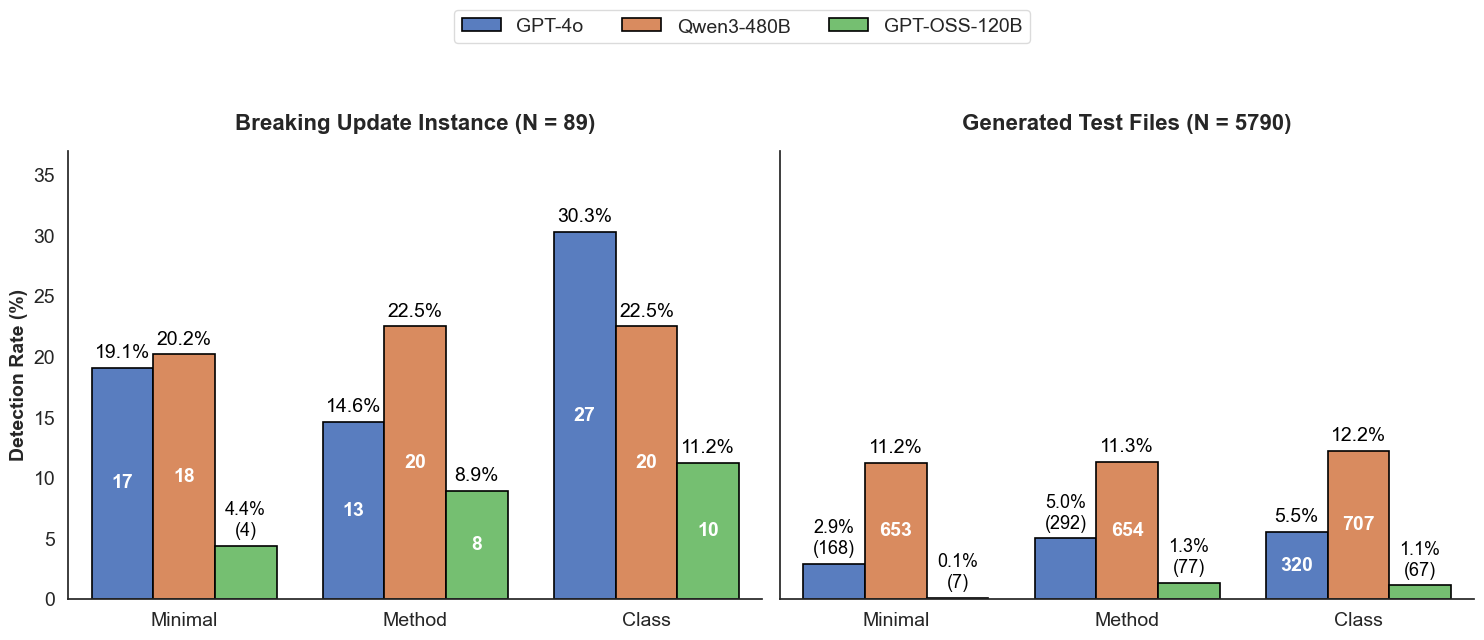

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Prepare the Data 
data = {
    'Model': [
        'GPT-4o', 'GPT-4o', 'GPT-4o',
        'Qwen3-480B', 'Qwen3-480B', 'Qwen3-480B',
        'GPT-OSS-120B', 'GPT-OSS-120B', 'GPT-OSS-120B'
    ],
    'Context': [
        'Minimal', 'Method', 'Class',
        'Minimal', 'Method', 'Class',
        'Minimal', 'Method', 'Class'
    ],
    # Detection Rates (%)
    'Instance_Det_Rate': [19.1, 14.6, 30.3, 20.2, 22.5, 22.5, 4.4, 8.9, 11.2],
    'TestFile_Det_Rate': [2.9, 5.0, 5.5, 11.2, 11.3, 12.2, 0.1, 1.3, 1.1],
    # Raw Detected Counts (#)
    'Instance_Count': [17, 13, 27, 18, 20, 20, 4, 8, 10],
    'TestFile_Count': [168, 292, 320, 653, 654, 707, 7, 77, 67]
}

df = pd.DataFrame(data)

# 2. Set up the plotting style
# Changed to "white" to remove horizontal gridlines
sns.set_theme(style="white")
plt.rcParams.update({'font.size': 12, 'pdf.fonttype': 42})

# Create a figure with 2 side-by-side subplots sharing the same Y-axis
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# ---------------------------------------------------
# Left Panel: Instance Level (N = 89)
# ---------------------------------------------------
sns.barplot(
    data=df, x='Context', y='Instance_Det_Rate', hue='Model', 
    ax=axes[0], palette='muted', edgecolor='black', linewidth=1.2
)

axes[0].set_title('Breaking Update Instance (N = 89)', fontweight='bold', pad=15, fontsize=16)
axes[0].set_xlabel('', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Detection Rate (%)', fontweight='bold', fontsize=14)
axes[0].set_ylim(0, 37) 

# Increase font size for axis tick labels (Minimal, Method, Class, and Y-axis numbers)
axes[0].tick_params(axis='both', labelsize=14)

# Add Labels: Slice patches to strictly match DataFrame length
for i, p in enumerate(axes[0].patches[:len(df)]):
    height = p.get_height()
    count = df['Instance_Count'].iloc[i]
    
    if height > 0:
        if height > 5.0:
            # Percentage on top
            axes[0].text(p.get_x() + p.get_width()/2., height + 0.5, 
                         f'{height:.1f}%', ha='center', va='bottom', color='black', fontsize=14)
            # Raw Count inside
            axes[0].text(p.get_x() + p.get_width()/2., height / 2, 
                         f'{count}', ha='center', va='center', color='white', fontweight='bold', fontsize=14)
        else:
            # Stacked neatly above if the bar is too short
            axes[0].text(p.get_x() + p.get_width()/2., height + 0.5, 
                         f'{height:.1f}%\n({count})', ha='center', va='bottom', color='black', fontsize=13)

# ---------------------------------------------------
# Right Panel: Test File Level (N = 5790)
# ---------------------------------------------------
sns.barplot(
    data=df, x='Context', y='TestFile_Det_Rate', hue='Model', 
    ax=axes[1], palette='muted', edgecolor='black', linewidth=1.2
)

axes[1].set_title('Generated Test Files (N = 5790)', fontweight='bold', pad=15, fontsize=16)
axes[1].set_xlabel('', fontweight='bold', fontsize=14)
axes[1].set_ylabel('') # Clear y-label since it is shared

# Increase font size for axis tick labels
axes[1].tick_params(axis='both', labelsize=14)

# Add Labels: Slice patches to strictly match DataFrame length
for i, p in enumerate(axes[1].patches[:len(df)]):
    height = p.get_height()
    count = df['TestFile_Count'].iloc[i]
    
    if height > 0:
        if height > 5.0:
            # Percentage on top
            axes[1].text(p.get_x() + p.get_width()/2., height + 0.5, 
                         f'{height:.1f}%', ha='center', va='bottom', color='black', fontsize=14)
            # Raw Count inside
            axes[1].text(p.get_x() + p.get_width()/2., height / 2, 
                         f'{count}', ha='center', va='center', color='white', fontweight='bold', fontsize=14)
        else:
            # Stacked neatly above if the bar is too short
            axes[1].text(p.get_x() + p.get_width()/2., height + 0.5, 
                         f'{height:.1f}%\n({count})', ha='center', va='bottom', color='black', fontsize=13)

# ---------------------------------------------------
# Final Layout Adjustments
# ---------------------------------------------------
# 1. Extract the legend handles and labels from the first subplot
handles, labels = axes[0].get_legend_handles_labels()

# 2. Remove the individual subplot legends created by Seaborn
if axes[0].get_legend() is not None:
    axes[0].get_legend().remove()
if axes[1].get_legend() is not None:
    axes[1].get_legend().remove()

# 3. Create a single, centered figure-level legend at the top
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.08), 
           ncol=3, fontsize=14, frameon=True, edgecolor='lightgrey')

# Removes the top and right chart borders for a cleaner, modern look
sns.despine()

# Use 'rect' to scale the subplots down slightly so the top legend fits
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

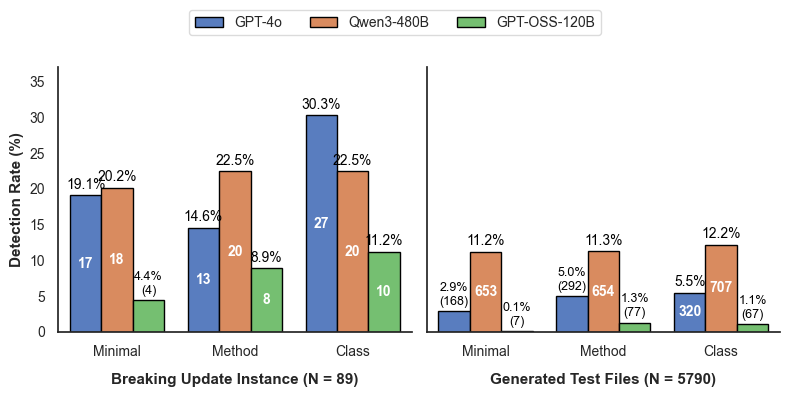

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Prepare the Data 
data = {
    'Model': [
        'GPT-4o', 'GPT-4o', 'GPT-4o',
        'Qwen3-480B', 'Qwen3-480B', 'Qwen3-480B',
        'GPT-OSS-120B', 'GPT-OSS-120B', 'GPT-OSS-120B'
    ],
    'Context': [
        'Minimal', 'Method', 'Class',
        'Minimal', 'Method', 'Class',
        'Minimal', 'Method', 'Class'
    ],
    'Instance_Det_Rate': [19.1, 14.6, 30.3, 20.2, 22.5, 22.5, 4.4, 8.9, 11.2],
    'TestFile_Det_Rate': [2.9, 5.0, 5.5, 11.2, 11.3, 12.2, 0.1, 1.3, 1.1],
    'Instance_Count': [17, 13, 27, 18, 20, 20, 4, 8, 10],
    'TestFile_Count': [168, 292, 320, 653, 654, 707, 7, 77, 67]
}

df = pd.DataFrame(data)

# 2. Set up the plotting style
sns.set_theme(style="white")
plt.rcParams.update({'font.size': 10, 'pdf.fonttype': 42})

# Create a much more compact figure suitable for a single column
fig, axes = plt.subplots(1, 2, figsize=(8, 3.8), sharey=True)

# ---------------------------------------------------
# Left Panel: Instance Level (N = 89)
# ---------------------------------------------------
sns.barplot(
    data=df, x='Context', y='Instance_Det_Rate', hue='Model', 
    ax=axes[0], palette='muted', edgecolor='black', linewidth=1.0
)

# Move the title to the x-axis label to save vertical space
axes[0].set_xlabel('Breaking Update Instance (N = 89)', fontweight='bold', fontsize=11, labelpad=10)
axes[0].set_ylabel('Detection Rate (%)', fontweight='bold', fontsize=11)
axes[0].set_ylim(0, 37) 
axes[0].tick_params(axis='both', labelsize=10)

# Add Labels
for i, p in enumerate(axes[0].patches[:len(df)]):
    height = p.get_height()
    count = df['Instance_Count'].iloc[i]
    
    if height > 0:
        if height > 5.0:
            axes[0].text(p.get_x() + p.get_width()/2., height + 0.5, 
                         f'{height:.1f}%', ha='center', va='bottom', color='black', fontsize=10)
            axes[0].text(p.get_x() + p.get_width()/2., height / 2, 
                         f'{count}', ha='center', va='center', color='white', fontweight='bold', fontsize=10)
        else:
            axes[0].text(p.get_x() + p.get_width()/2., height + 0.5, 
                         f'{height:.1f}%\n({count})', ha='center', va='bottom', color='black', fontsize=9)

# ---------------------------------------------------
# Right Panel: Test File Level (N = 5790)
# ---------------------------------------------------
sns.barplot(
    data=df, x='Context', y='TestFile_Det_Rate', hue='Model', 
    ax=axes[1], palette='muted', edgecolor='black', linewidth=1.0
)

# Move the title to the x-axis label
axes[1].set_xlabel('Generated Test Files (N = 5790)', fontweight='bold', fontsize=11, labelpad=10)
axes[1].set_ylabel('')
axes[1].tick_params(axis='both', labelsize=10)

# Add Labels
for i, p in enumerate(axes[1].patches[:len(df)]):
    height = p.get_height()
    count = df['TestFile_Count'].iloc[i]
    
    if height > 0:
        if height > 5.0:
            axes[1].text(p.get_x() + p.get_width()/2., height + 0.5, 
                         f'{height:.1f}%', ha='center', va='bottom', color='black', fontsize=10)
            axes[1].text(p.get_x() + p.get_width()/2., height / 2, 
                         f'{count}', ha='center', va='center', color='white', fontweight='bold', fontsize=10)
        else:
            axes[1].text(p.get_x() + p.get_width()/2., height + 0.5, 
                         f'{height:.1f}%\n({count})', ha='center', va='bottom', color='black', fontsize=9)

# ---------------------------------------------------
# Final Layout Adjustments
# ---------------------------------------------------
# Extract legend handles
handles, labels = axes[0].get_legend_handles_labels()

# Remove individual legends
if axes[0].get_legend() is not None:
    axes[0].get_legend().remove()
if axes[1].get_legend() is not None:
    axes[1].get_legend().remove()

# Create top shared legend, tighter to the plot
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), 
           ncol=3, fontsize=10, frameon=True, edgecolor='lightgrey')

sns.despine()

# Adjust 'rect' to leave just enough room for the legend on top
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

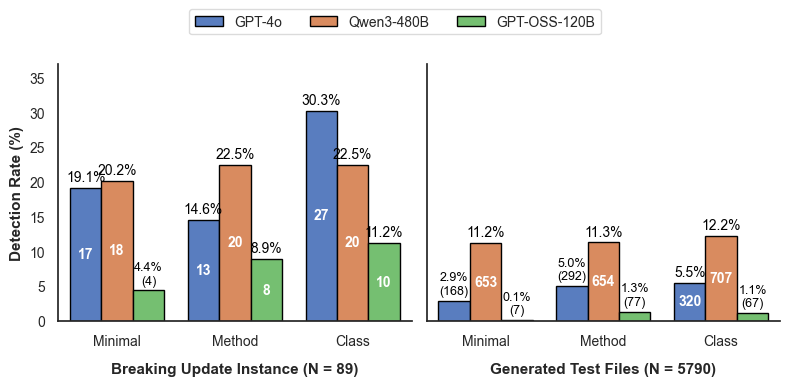

In [21]:
import matplotlib.pyplot as plt
import seaborn as pd
import pandas as pd
import seaborn as sns

# 1. Prepare the Data 
data = {
    'Model': [
        'GPT-4o', 'GPT-4o', 'GPT-4o',
        'Qwen3-480B', 'Qwen3-480B', 'Qwen3-480B',
        'GPT-OSS-120B', 'GPT-OSS-120B', 'GPT-OSS-120B'
    ],
    'Context': [
        'Minimal', 'Method', 'Class',
        'Minimal', 'Method', 'Class',
        'Minimal', 'Method', 'Class'
    ],
    'Instance_Det_Rate': [19.1, 14.6, 30.3, 20.2, 22.5, 22.5, 4.4, 8.9, 11.2],
    'TestFile_Det_Rate': [2.9, 5.0, 5.5, 11.2, 11.3, 12.2, 0.1, 1.3, 1.1],
    'Instance_Count': [17, 13, 27, 18, 20, 20, 4, 8, 10],
    'TestFile_Count': [168, 292, 320, 653, 654, 707, 7, 77, 67]
}

df = pd.DataFrame(data)

# 2. Set up the plotting style
sns.set_theme(style="white")
plt.rcParams.update({'font.size': 10, 'pdf.fonttype': 42})

# Create a much more compact figure suitable for a single column
fig, axes = plt.subplots(1, 2, figsize=(8, 3.8), sharey=True)

# ---------------------------------------------------
# Left Panel: Instance Level (N = 89)
# ---------------------------------------------------
sns.barplot(
    data=df, x='Context', y='Instance_Det_Rate', hue='Model', 
    ax=axes[0], palette='muted', edgecolor='black', linewidth=1.0
)

# Move the title to the x-axis label to save vertical space
axes[0].set_xlabel('Breaking Update Instance (N = 89)', fontweight='bold', fontsize=11, labelpad=10)
axes[0].set_ylabel('Detection Rate (%)', fontweight='bold', fontsize=11)
axes[0].set_ylim(0, 37) 
axes[0].tick_params(axis='both', labelsize=10)

# Add Labels
for i, p in enumerate(axes[0].patches[:len(df)]):
    height = p.get_height()
    count = df['Instance_Count'].iloc[i]
    
    if height > 0:
        if height > 5.0:
            axes[0].text(p.get_x() + p.get_width()/2., height + 0.5, 
                         f'{height:.1f}%', ha='center', va='bottom', color='black', fontsize=10)
            axes[0].text(p.get_x() + p.get_width()/2., height / 2, 
                         f'{count}', ha='center', va='center', color='white', fontweight='bold', fontsize=10)
        else:
            axes[0].text(p.get_x() + p.get_width()/2., height + 0.5, 
                         f'{height:.1f}%\n({count})', ha='center', va='bottom', color='black', fontsize=9)

# ---------------------------------------------------
# Right Panel: Test File Level (N = 5790)
# ---------------------------------------------------
sns.barplot(
    data=df, x='Context', y='TestFile_Det_Rate', hue='Model', 
    ax=axes[1], palette='muted', edgecolor='black', linewidth=1.0
)

# Move the title to the x-axis label
axes[1].set_xlabel('Generated Test Files (N = 5790)', fontweight='bold', fontsize=11, labelpad=10)
axes[1].set_ylabel('')
axes[1].tick_params(axis='both', labelsize=10)

# Add Labels
for i, p in enumerate(axes[1].patches[:len(df)]):
    height = p.get_height()
    count = df['TestFile_Count'].iloc[i]
    
    if height > 0:
        if height > 5.0:
            axes[1].text(p.get_x() + p.get_width()/2., height + 0.5, 
                         f'{height:.1f}%', ha='center', va='bottom', color='black', fontsize=10)
            axes[1].text(p.get_x() + p.get_width()/2., height / 2, 
                         f'{count}', ha='center', va='center', color='white', fontweight='bold', fontsize=10)
        else:
            axes[1].text(p.get_x() + p.get_width()/2., height + 0.5, 
                         f'{height:.1f}%\n({count})', ha='center', va='bottom', color='black', fontsize=9)

# ---------------------------------------------------
# Final Layout Adjustments & Saving
# ---------------------------------------------------
# Extract legend handles
handles, labels = axes[0].get_legend_handles_labels()

# Remove individual legends
if axes[0].get_legend() is not None:
    axes[0].get_legend().remove()
if axes[1].get_legend() is not None:
    axes[1].get_legend().remove()

# Increase 'rect' top limit to allow the plots to take up more vertical space
plt.tight_layout(rect=[0, 0, 1, 0.90])

# Anchor the bottom ('lower center') of the legend slightly above the plots (y=0.92)
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.92), 
           ncol=3, fontsize=10, frameon=True, edgecolor='lightgrey')

# Remove top and right borders
sns.despine()

# Save the figure BEFORE showing it, using bbox_inches='tight' to prevent cropping
plt.savefig('breaking_update_results.pdf', format='pdf', bbox_inches='tight', dpi=300)

# Display the plot
plt.show()

## Split of breaking_update_results.pdf into two separate plots

1. Instance-level detection rate, but bars distributed per **model** (context variant as hue), instead of per context variant.
2. Distribution (violin) of the number of test files that detected the break, per instance, split by model x context — using only instances where detection succeeded (`DetectedTestFileCount > 0`), from `CountingNoOfTestCasesToReport/output/DetectedTestCount/*.json`.

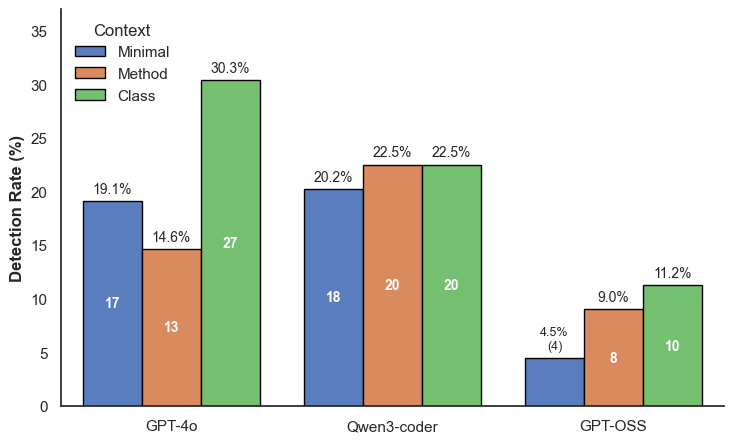

 model_disp context_variant  count  rate_pct
     GPT-4o         Minimal     17 19.101124
     GPT-4o          Method     13 14.606742
     GPT-4o           Class     27 30.337079
Qwen3-coder         Minimal     18 20.224719
Qwen3-coder          Method     20 22.471910
Qwen3-coder           Class     20 22.471910
    GPT-OSS         Minimal      4  4.494382
    GPT-OSS          Method      8  8.988764
    GPT-OSS           Class     10 11.235955


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Data: instance-level detection, N=89 ─────────────────────────────────────
inst = pd.read_csv("RQ2_data/Stats/bc_detection_per_instance.csv")
det = pd.read_csv("RQ2_data/Stats/detected_bc_across_models.csv")
n_instances = inst["custom_id"].nunique()

MODEL_DISPLAY = {"GPT-4o": "GPT-4o", "Qwen-480B": "Qwen3-coder", "GPTOSS-120b": "GPT-OSS"}
MODEL_ORDER = ["GPT-4o", "Qwen3-coder", "GPT-OSS"]
CONTEXT_ORDER = ["Minimal", "Method", "Class"]

det["model_disp"] = det["model"].map(MODEL_DISPLAY)
assert det["model_disp"].notna().all(), f"Unmapped model(s): {det.loc[det['model_disp'].isna(), 'model'].unique()}"

grid = pd.MultiIndex.from_product([MODEL_ORDER, CONTEXT_ORDER], names=["model_disp", "context_variant"])
counts = (
    det.groupby(["model_disp", "context_variant"])["custom_id"]
    .nunique()
    .reindex(grid, fill_value=0)
    .reset_index(name="count")
)
counts["rate_pct"] = counts["count"] / n_instances * 100

# ── Plot: bars distributed per MODEL, context variant as hue ────────────────
# Same style/palette as the original breaking_update_results.pdf (sns "muted")
sns.set_theme(style="white")
plt.rcParams.update({"font.size": 12, "pdf.fonttype": 42})

fig, ax = plt.subplots(figsize=(7.5, 4.6))
sns.barplot(
    data=counts, x="model_disp", y="rate_pct", hue="context_variant",
    order=MODEL_ORDER, hue_order=CONTEXT_ORDER,
    palette="muted", ax=ax, edgecolor="black", linewidth=1.0,
)

ax.set_xlabel("")
ax.set_ylabel("Detection Rate (%)", fontweight="bold")
axes[0].set_xlabel('Breaking Update Instance (N = 89)', fontweight='bold', fontsize=11, labelpad=10)
# ax.set_title(f"Breaking Update Instance Detection (N = {n_instances})", fontweight="bold", pad=15)
ax.set_ylim(0, 37)
sns.despine(ax=ax)

lookup = counts.set_index(["model_disp", "context_variant"])
for container, context in zip(ax.containers, CONTEXT_ORDER):
    for bar, model in zip(container, MODEL_ORDER):
        height = bar.get_height()
        count = int(lookup.loc[(model, context), "count"])
        if height <= 0:
            continue
        x = bar.get_x() + bar.get_width() / 2
        if height > 5.0:
            ax.text(x, height + 0.5, f"{height:.1f}%", ha="center", va="bottom", fontsize=10)
            ax.text(x, height / 2, f"{count}", ha="center", va="center",
                     color="white", fontweight="bold", fontsize=10)
        else:
            ax.text(x, height + 0.5, f"{height:.1f}%\n({count})", ha="center", va="bottom", fontsize=9)

ax.legend(title="Context", frameon=False, loc="upper left")

plt.tight_layout()
plt.savefig("rq2_instance_by_model.pdf", format="pdf", bbox_inches="tight", dpi=300)
plt.show()
print(counts.to_string(index=False))

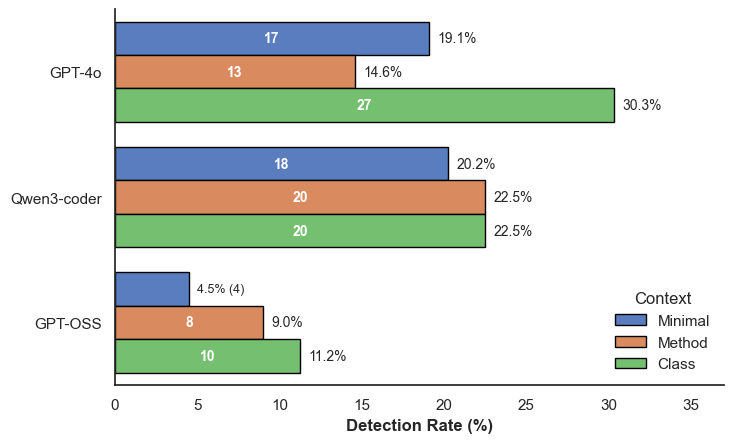

 model_disp context_variant  count  rate_pct
     GPT-4o         Minimal     17 19.101124
     GPT-4o          Method     13 14.606742
     GPT-4o           Class     27 30.337079
Qwen3-coder         Minimal     18 20.224719
Qwen3-coder          Method     20 22.471910
Qwen3-coder           Class     20 22.471910
    GPT-OSS         Minimal      4  4.494382
    GPT-OSS          Method      8  8.988764
    GPT-OSS           Class     10 11.235955


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Data: instance-level detection, N=89 ─────────────────────────────────────
inst = pd.read_csv("RQ2_data/Stats/bc_detection_per_instance.csv")
det = pd.read_csv("RQ2_data/Stats/detected_bc_across_models.csv")
n_instances = inst["custom_id"].nunique()

MODEL_DISPLAY = {"GPT-4o": "GPT-4o", "Qwen-480B": "Qwen3-coder", "GPTOSS-120b": "GPT-OSS"}
MODEL_ORDER = ["GPT-4o", "Qwen3-coder", "GPT-OSS"]
CONTEXT_ORDER = ["Minimal", "Method", "Class"]

det["model_disp"] = det["model"].map(MODEL_DISPLAY)
assert det["model_disp"].notna().all(), f"Unmapped model(s): {det.loc[det['model_disp'].isna(), 'model'].unique()}"

grid = pd.MultiIndex.from_product([MODEL_ORDER, CONTEXT_ORDER], names=["model_disp", "context_variant"])
counts = (
    det.groupby(["model_disp", "context_variant"])["custom_id"]
    .nunique()
    .reindex(grid, fill_value=0)
    .reset_index(name="count")
)
counts["rate_pct"] = counts["count"] / n_instances * 100

# ── Plot: horizontal bars, models on y-axis, context as hue ─────────────────
sns.set_theme(style="white")
plt.rcParams.update({"font.size": 12, "pdf.fonttype": 42})

fig, ax = plt.subplots(figsize=(7.5, 4.6))
sns.barplot(
    data=counts, x="rate_pct", y="model_disp", hue="context_variant",
    order=MODEL_ORDER, hue_order=CONTEXT_ORDER, orient="h",
    palette="muted", ax=ax, edgecolor="black", linewidth=1.0,
)

ax.set_ylabel("")
ax.set_xlabel("Detection Rate (%)", fontweight="bold")
ax.set_xlim(0, 37)
sns.despine(ax=ax)

lookup = counts.set_index(["model_disp", "context_variant"])
for container, context in zip(ax.containers, CONTEXT_ORDER):
    for bar, model in zip(container, MODEL_ORDER):
        width = bar.get_width()
        count = int(lookup.loc[(model, context), "count"])
        if width <= 0:
            continue
        y = bar.get_y() + bar.get_height() / 2
        if width > 5.0:
            ax.text(width + 0.5, y, f"{width:.1f}%", ha="left", va="center", fontsize=10)
            ax.text(width / 2, y, f"{count}", ha="center", va="center",
                    color="white", fontweight="bold", fontsize=10)
        else:
            ax.text(width + 0.5, y, f"{width:.1f}% ({count})", ha="left", va="center", fontsize=9)

ax.legend(title="Context", frameon=False, loc="lower right")

plt.tight_layout()
plt.savefig("rq2_instance_by_model.pdf", format="pdf", bbox_inches="tight", dpi=300)
plt.show()
print(counts.to_string(index=False))

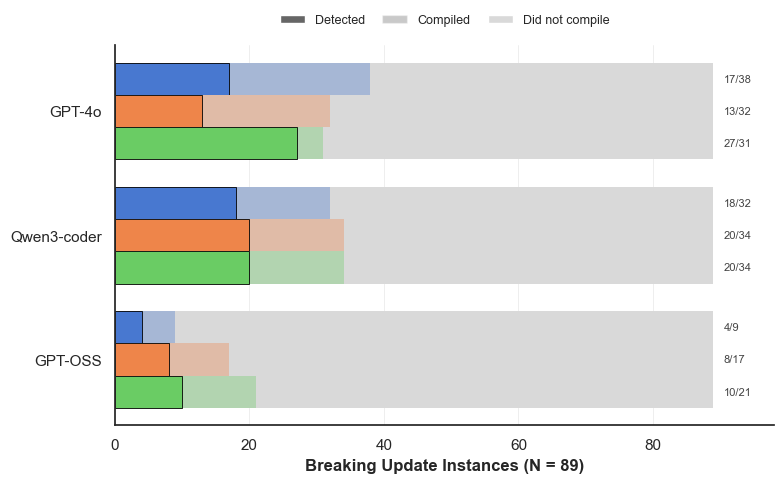

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ... (keep your existing data-loading block that builds `counts`) ...

sns.set_theme(style="white")
plt.rcParams.update({"font.size": 12, "pdf.fonttype": 42})

N_TOTAL = n_instances  # 89
pal = dict(zip(CONTEXT_ORDER, sns.color_palette("muted", len(CONTEXT_ORDER))))
GREY = "0.85"

lookup = counts.set_index(["model_disp", "context_variant"])
# detected counts, straight from your data
DET = {m: {c: int(lookup.loc[(m, c), "count"]) for c in CONTEXT_ORDER} for m in MODEL_ORDER}
# compiled/valid counts — swap for a data-derived source if you have one
VALID = {
    "GPT-4o":      {"Minimal": 38, "Method": 32, "Class": 31},
    "Qwen3-coder": {"Minimal": 32, "Method": 34, "Class": 34},
    "GPT-OSS":     {"Minimal": 9,  "Method": 17, "Class": 21},
}

fig, ax = plt.subplots(figsize=(8, 5))
y = np.arange(len(MODEL_ORDER))
h = 0.26

for j, ctx in enumerate(CONTEXT_ORDER):
    yy = y + (j - 1) * h
    valid_vals = [VALID[m][ctx] for m in MODEL_ORDER]
    det_vals   = [DET[m][ctx]   for m in MODEL_ORDER]
    # layer 1: grey backdrop to 89 (did not compile)
    ax.barh(yy, [N_TOTAL] * len(MODEL_ORDER), h, color=GREY, edgecolor="none")
    # layer 2: compiled/valid (pale context colour)
    ax.barh(yy, valid_vals, h, color=pal[ctx], alpha=0.35, edgecolor="none")
    # layer 3: detected (solid context colour)
    ax.barh(yy, det_vals, h, color=pal[ctx], edgecolor="black", linewidth=0.6)
    # label detected/valid just past the bar end
    for yi, d, v in zip(yy, det_vals, valid_vals):
        ax.text(N_TOTAL + 1.5, yi, f"{d}/{v}", ha="left", va="center",
                fontsize=8, color="#444")

ax.set_yticks(y)
ax.set_yticklabels(MODEL_ORDER)
ax.set_xlabel(f"Breaking Update Instances (N = {N_TOTAL})", fontweight="bold")
ax.set_ylabel("")
ax.set_xlim(0, N_TOTAL + 9)
ax.invert_yaxis()  # GPT-4o on top
ax.grid(axis="x", color="0.92", linewidth=0.6)
ax.set_axisbelow(True)
sns.despine(ax=ax)

# Two legends: context colour, and what the shading means
ctx_handles = [mpatches.Patch(facecolor=pal[c], label=c) for c in CONTEXT_ORDER]
shade_handles = [
    mpatches.Patch(facecolor="0.4", label="Detected"),
    mpatches.Patch(facecolor="0.4", alpha=0.35, label="Compiled"),
    mpatches.Patch(facecolor=GREY, label="Did not compile"),
]
leg1 = ax.legend(handles=ctx_handles, frameon=False, ncol=3, fontsize=9,
                 loc="lower center", bbox_to_anchor=(0.5, 1.10), columnspacing=1.4)
ax.add_artist(leg1)
ax.legend(handles=shade_handles, frameon=False, ncol=3, fontsize=9,
          loc="lower center", bbox_to_anchor=(0.5, 1.02), columnspacing=1.4)

plt.tight_layout()
plt.savefig("rq2_instance_layered.pdf", format="pdf", bbox_inches="tight", dpi=300)
plt.show()

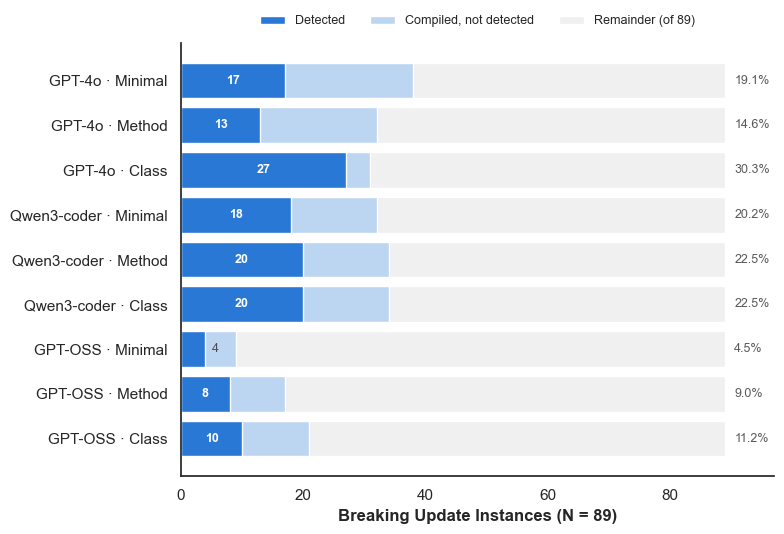

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="white")
plt.rcParams.update({"font.size": 12, "pdf.fonttype": 42})

N_TOTAL = n_instances  # 89
lookup = counts.set_index(["model_disp", "context_variant"])
DET = {m: {c: int(lookup.loc[(m, c), "count"]) for c in CONTEXT_ORDER} for m in MODEL_ORDER}
VALID = {
    "GPT-4o":      {"Minimal": 38, "Method": 32, "Class": 31},
    "Qwen3-coder": {"Minimal": 32, "Method": 34, "Class": 34},
    "GPT-OSS":     {"Minimal": 9,  "Method": 17, "Class": 21},
}

DARK  = "#2a78d6"   # detected
LIGHT = "#bcd6f2"   # compiled, not detected (pale blue)
FAINT = "0.94"      # remainder up to 89 (barely-there)

rows = [(f"{m} · {c}", DET[m][c], VALID[m][c])
        for m in MODEL_ORDER for c in CONTEXT_ORDER]
labels = [r[0] for r in rows]
y = np.arange(len(rows))[::-1]  # first row on top

fig, ax = plt.subplots(figsize=(8, 5.5))
for yi, (lab, det, val) in zip(y, rows):
    ax.barh(yi, N_TOTAL, color=FAINT, edgecolor="white", linewidth=1.0)   # faint track to 89
    ax.barh(yi, val,     color=LIGHT, edgecolor="white", linewidth=1.0)   # compiled
    ax.barh(yi, det,     color=DARK,  edgecolor="white", linewidth=1.0)   # detected
    pct = det / N_TOTAL * 100
    # detected count inside dark segment (or just past it if too short)
    if det > 4:
        ax.text(det / 2, yi, f"{det}", ha="center", va="center",
                color="white", fontweight="bold", fontsize=9)
    else:
        ax.text(det + 1, yi, f"{det}", ha="left", va="center",
                color="0.3", fontsize=9)
    # % of 89 at the far right, past the full track
    ax.text(N_TOTAL + 1.5, yi, f"{pct:.1f}%", ha="left", va="center",
            fontsize=9, color="0.35")

ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlim(0, N_TOTAL + 8)
ax.set_xlabel(f"Breaking Update Instances (N = {N_TOTAL})", fontweight="bold")
sns.despine(ax=ax)

legend = [
    mpatches.Patch(facecolor=DARK,  label="Detected"),
    mpatches.Patch(facecolor=LIGHT, label="Compiled, not detected"),
    mpatches.Patch(facecolor=FAINT, label="Remainder (of 89)"),
]
ax.legend(handles=legend, frameon=False, ncol=3, fontsize=9,
          loc="lower center", bbox_to_anchor=(0.5, 1.01))

plt.tight_layout()
plt.savefig("rq2_instance_faint89.pdf", format="pdf", bbox_inches="tight", dpi=300)
plt.show()

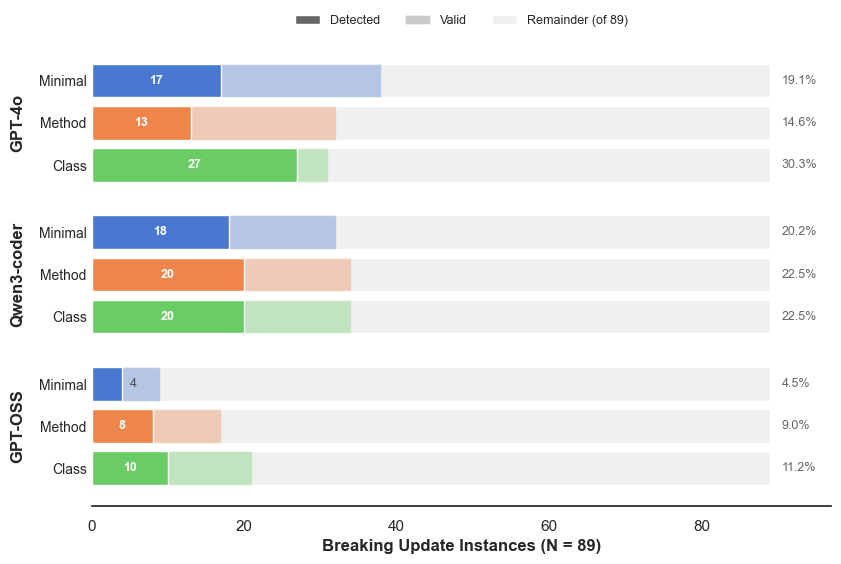

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="white")
plt.rcParams.update({"font.size": 12, "pdf.fonttype": 42})

N_TOTAL = n_instances  # 89
lookup = counts.set_index(["model_disp", "context_variant"])
DET = {m: {c: int(lookup.loc[(m, c), "count"]) for c in CONTEXT_ORDER} for m in MODEL_ORDER}
VALID = {
    "GPT-4o":      {"Minimal": 38, "Method": 32, "Class": 31},
    "Qwen3-coder": {"Minimal": 32, "Method": 34, "Class": 34},
    "GPT-OSS":     {"Minimal": 9,  "Method": 17, "Class": 21},
}
pal = dict(zip(CONTEXT_ORDER, sns.color_palette("muted", len(CONTEXT_ORDER))))
FAINT = "0.94"

rows, ypos, model_spans = [], [], {}
y = 0.0
for m in MODEL_ORDER:
    start = y
    for c in CONTEXT_ORDER:
        rows.append((m, c, DET[m][c], VALID[m][c]))
        ypos.append(y)
        y += 1
    model_spans[m] = (start, y - 1)
    y += 0.6

ypos = np.array(ypos)
ymax = ypos.max()
ypos_plot = ymax - ypos

fig, ax = plt.subplots(figsize=(8.5, 5.8))
for (m, c, det, val), yp in zip(rows, ypos_plot):
    col = pal[c]
    ax.barh(yp, N_TOTAL, height=0.8, color=FAINT, edgecolor="white", linewidth=1.0)
    ax.barh(yp, val, height=0.8, color=col, alpha=0.35, edgecolor="white", linewidth=1.0)
    ax.barh(yp, det, height=0.8, color=col, edgecolor="white", linewidth=1.0)
    if det > 4:
        ax.text(det / 2, yp, f"{det}", ha="center", va="center",
                color="white", fontweight="bold", fontsize=9)
    else:
        ax.text(det + 1, yp, f"{det}", ha="left", va="center", color="0.3", fontsize=9)
    ax.text(N_TOTAL + 1.5, yp, f"{det / N_TOTAL * 100:.1f}%",
            ha="left", va="center", fontsize=9, color="0.4")

ax.set_yticks(ypos_plot)
ax.set_yticklabels([c for (_, c, _, _) in rows], fontsize=10)
for m, (s, e) in model_spans.items():
    center = ymax - (s + e) / 2
    ax.text(-0.09, center, m, transform=ax.get_yaxis_transform(),
            ha="right", va="center", fontweight="bold", fontsize=12, rotation=90)

ax.set_xlim(0, N_TOTAL + 8)
ax.set_xlabel(f"Breaking Update Instances (N = {N_TOTAL})", fontweight="bold")
ax.tick_params(axis="y", length=0)
sns.despine(ax=ax, left=True)

ctx_handles = [mpatches.Patch(facecolor=pal[c], label=c) for c in CONTEXT_ORDER]
shade_handles = [
    mpatches.Patch(facecolor="0.4", label="Detected"),
    mpatches.Patch(facecolor="0.4", alpha=0.35, label="Valid"),
    mpatches.Patch(facecolor=FAINT, label="Remainder (of 89)"),
]
leg1 = ax.legend(handles=ctx_handles, frameon=False, ncol=3, fontsize=9,
                 loc="lower center", bbox_to_anchor=(0.5, 1.08))
ax.add_artist(leg1)
ax.legend(handles=shade_handles, frameon=False, ncol=3, fontsize=9,
          loc="lower center", bbox_to_anchor=(0.5, 1.01))

plt.tight_layout()
plt.savefig("rq2_instance_grouped.pdf", format="pdf", bbox_inches="tight", dpi=300)
plt.show()

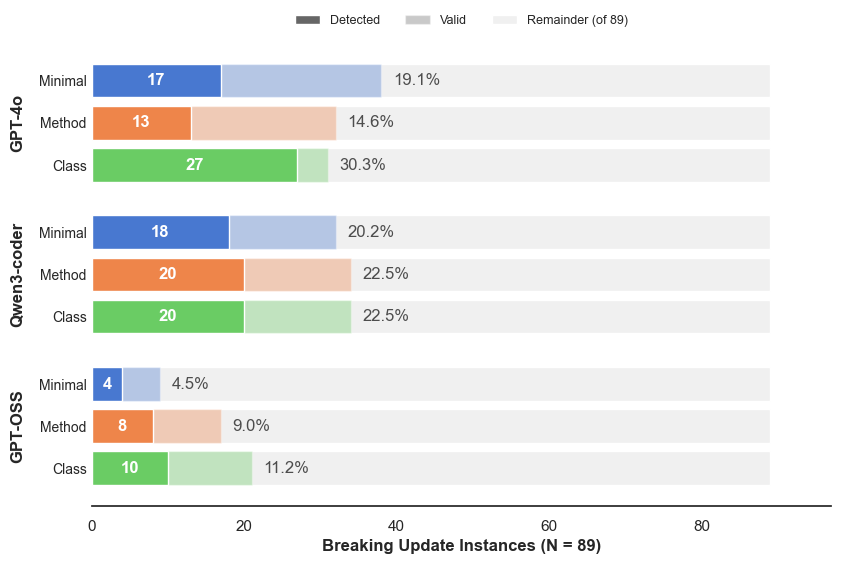

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="white")
plt.rcParams.update({"font.size": 12, "pdf.fonttype": 42})

N_TOTAL = n_instances  # 89
lookup = counts.set_index(["model_disp", "context_variant"])
DET = {m: {c: int(lookup.loc[(m, c), "count"]) for c in CONTEXT_ORDER} for m in MODEL_ORDER}
VALID = {
    "GPT-4o":      {"Minimal": 38, "Method": 32, "Class": 31},
    "Qwen3-coder": {"Minimal": 32, "Method": 34, "Class": 34},
    "GPT-OSS":     {"Minimal": 9,  "Method": 17, "Class": 21},
}
pal = dict(zip(CONTEXT_ORDER, sns.color_palette("muted", len(CONTEXT_ORDER))))
FAINT = "0.94"

rows, ypos, model_spans = [], [], {}
y = 0.0
for m in MODEL_ORDER:
    start = y
    for c in CONTEXT_ORDER:
        rows.append((m, c, DET[m][c], VALID[m][c]))
        ypos.append(y)
        y += 1
    model_spans[m] = (start, y - 1)
    y += 0.6

ypos = np.array(ypos)
ymax = ypos.max()
ypos_plot = ymax - ypos

fig, ax = plt.subplots(figsize=(8.5, 5.8))
for (m, c, det, val), yp in zip(rows, ypos_plot):
    col = pal[c]
    ax.barh(yp, N_TOTAL, height=0.8, color=FAINT, edgecolor="white", linewidth=1.0)
    ax.barh(yp, val, height=0.8, color=col, alpha=0.35, edgecolor="white", linewidth=1.0)
    ax.barh(yp, det, height=0.8, color=col, edgecolor="white", linewidth=1.0)
    pct = det / N_TOTAL * 100
    # count inside the dark segment, % right after the segment ends
    ax.text(det / 2, yp, f"{det}", ha="center", va="center",
            color="white", fontweight="bold", fontsize=12)
    ax.text(val + 1.5, yp, f"{pct:.1f}%", ha="left", va="center",
            fontsize=12, color="0.3")

ax.set_yticks(ypos_plot)
ax.set_yticklabels([c for (_, c, _, _) in rows], fontsize=10)
for m, (s, e) in model_spans.items():
    center = ymax - (s + e) / 2
    ax.text(-0.09, center, m, transform=ax.get_yaxis_transform(),
            ha="right", va="center", fontweight="bold", fontsize=12, rotation=90)

ax.set_xlim(0, N_TOTAL + 8)
ax.set_xlabel(f"Breaking Update Instances (N = {N_TOTAL})", fontweight="bold")
ax.tick_params(axis="y", length=0)
sns.despine(ax=ax, left=True)

ctx_handles = [mpatches.Patch(facecolor=pal[c], label=c) for c in CONTEXT_ORDER]
shade_handles = [
    mpatches.Patch(facecolor="0.4", label="Detected"),
    mpatches.Patch(facecolor="0.4", alpha=0.35, label="Valid"),
    mpatches.Patch(facecolor=FAINT, label="Remainder (of 89)"),
]
leg1 = ax.legend(handles=ctx_handles, frameon=False, ncol=3, fontsize=9,
                 loc="lower center", bbox_to_anchor=(0.5, 1.08))
ax.add_artist(leg1)
ax.legend(handles=shade_handles, frameon=False, ncol=3, fontsize=9,
          loc="lower center", bbox_to_anchor=(0.5, 1.01))

plt.tight_layout()
plt.savefig("rq2_instance_grouped.pdf", format="pdf", bbox_inches="tight", dpi=300)
plt.show()

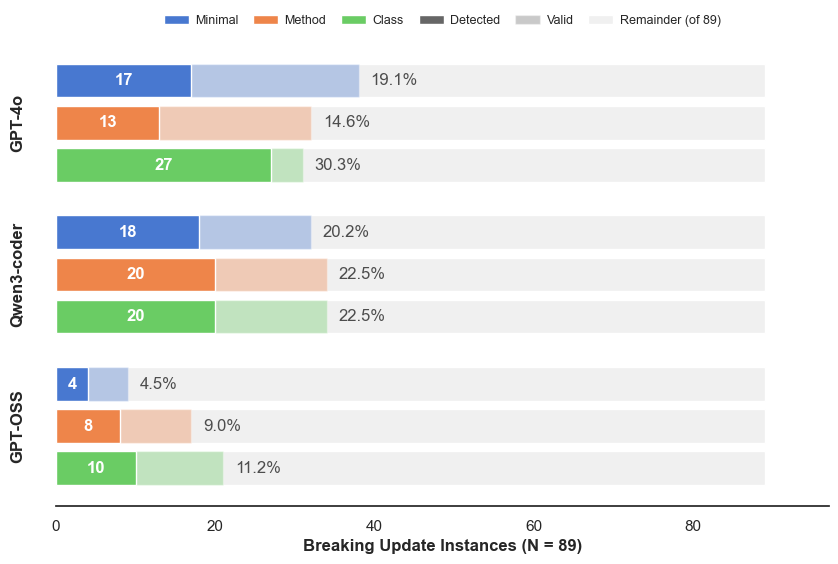

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="white")
plt.rcParams.update({"font.size": 12, "pdf.fonttype": 42})

N_TOTAL = n_instances  # 89
lookup = counts.set_index(["model_disp", "context_variant"])
DET = {m: {c: int(lookup.loc[(m, c), "count"]) for c in CONTEXT_ORDER} for m in MODEL_ORDER}
VALID = {
    "GPT-4o":      {"Minimal": 38, "Method": 32, "Class": 31},
    "Qwen3-coder": {"Minimal": 32, "Method": 34, "Class": 34},
    "GPT-OSS":     {"Minimal": 9,  "Method": 17, "Class": 21},
}
pal = dict(zip(CONTEXT_ORDER, sns.color_palette("muted", len(CONTEXT_ORDER))))
FAINT = "0.94"

rows, ypos, model_spans = [], [], {}
y = 0.0
for m in MODEL_ORDER:
    start = y
    for c in CONTEXT_ORDER:
        rows.append((m, c, DET[m][c], VALID[m][c]))
        ypos.append(y)
        y += 1
    model_spans[m] = (start, y - 1)
    y += 0.6

ypos = np.array(ypos)
ymax = ypos.max()
ypos_plot = ymax - ypos

fig, ax = plt.subplots(figsize=(8.5, 5.8))
for (m, c, det, val), yp in zip(rows, ypos_plot):
    col = pal[c]
    ax.barh(yp, N_TOTAL, height=0.8, color=FAINT, edgecolor="white", linewidth=1.0)
    ax.barh(yp, val, height=0.8, color=col, alpha=0.35, edgecolor="white", linewidth=1.0)
    ax.barh(yp, det, height=0.8, color=col, edgecolor="white", linewidth=1.0)
    pct = det / N_TOTAL * 100
    ax.text(det / 2, yp, f"{det}", ha="center", va="center",
            color="white", fontweight="bold", fontsize=12)
    ax.text(val + 1.5, yp, f"{pct:.1f}%", ha="left", va="center",
            fontsize=12, color="0.3")

# no per-bar context labels — context now lives in the legend
ax.set_yticks([])
for m, (s, e) in model_spans.items():
    center = ymax - (s + e) / 2
    ax.text(-0.04, center, m, transform=ax.get_yaxis_transform(),
            ha="right", va="center", fontweight="bold", fontsize=12, rotation=90)

ax.set_xlim(0, N_TOTAL + 8)
ax.set_xlabel(f"Breaking Update Instances (N = {N_TOTAL})", fontweight="bold")
ax.tick_params(axis="y", length=0)
sns.despine(ax=ax, left=True)

# single combined legend row: context hues + shade meanings
handles = (
    [mpatches.Patch(facecolor=pal[c], label=c) for c in CONTEXT_ORDER]
    + [mpatches.Patch(facecolor="0.4", label="Detected"),
       mpatches.Patch(facecolor="0.4", alpha=0.35, label="Valid"),
       mpatches.Patch(facecolor=FAINT, label="Remainder (of 89)")]
)
ax.legend(handles=handles, frameon=False, ncol=6, fontsize=9,
          loc="lower center", bbox_to_anchor=(0.5, 1.01),
          columnspacing=1.2, handletextpad=0.5)

plt.tight_layout()
plt.savefig("rq2_instance_grouped.pdf", format="pdf", bbox_inches="tight", dpi=300)
plt.show()

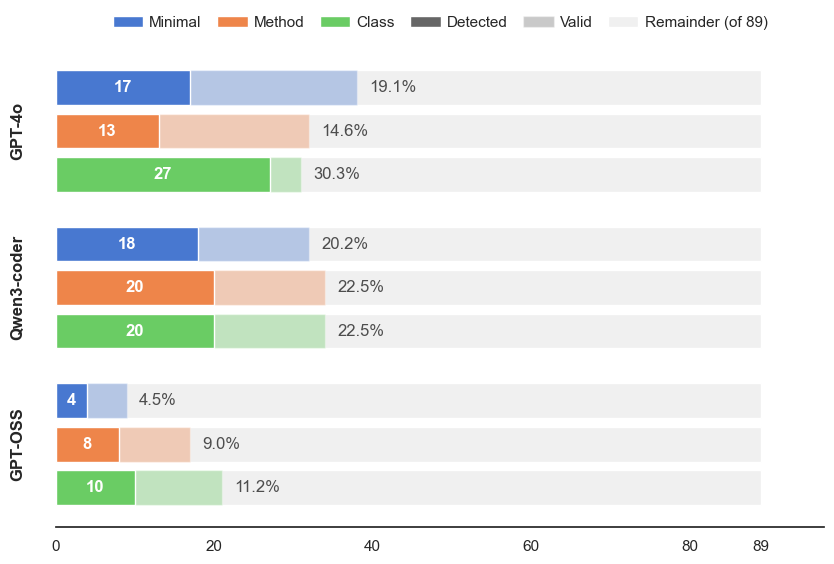

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="white")
plt.rcParams.update({"font.size": 12, "pdf.fonttype": 42})

N_TOTAL = n_instances  # 89
lookup = counts.set_index(["model_disp", "context_variant"])
DET = {m: {c: int(lookup.loc[(m, c), "count"]) for c in CONTEXT_ORDER} for m in MODEL_ORDER}
VALID = {
    "GPT-4o":      {"Minimal": 38, "Method": 32, "Class": 31},
    "Qwen3-coder": {"Minimal": 32, "Method": 34, "Class": 34},
    "GPT-OSS":     {"Minimal": 9,  "Method": 17, "Class": 21},
}
pal = dict(zip(CONTEXT_ORDER, sns.color_palette("muted", len(CONTEXT_ORDER))))
FAINT = "0.94"

rows, ypos, model_spans = [], [], {}
y = 0.0
for m in MODEL_ORDER:
    start = y
    for c in CONTEXT_ORDER:
        rows.append((m, c, DET[m][c], VALID[m][c]))
        ypos.append(y)
        y += 1
    model_spans[m] = (start, y - 1)
    y += 0.6

ypos = np.array(ypos)
ymax = ypos.max()
ypos_plot = ymax - ypos

fig, ax = plt.subplots(figsize=(8.5, 5.8))
for (m, c, det, val), yp in zip(rows, ypos_plot):
    col = pal[c]
    ax.barh(yp, N_TOTAL, height=0.8, color=FAINT, edgecolor="white", linewidth=1.0)
    ax.barh(yp, val, height=0.8, color=col, alpha=0.35, edgecolor="white", linewidth=1.0)
    ax.barh(yp, det, height=0.8, color=col, edgecolor="white", linewidth=1.0)
    pct = det / N_TOTAL * 100
    ax.text(det / 2, yp, f"{det}", ha="center", va="center",
            color="white", fontweight="bold", fontsize=12)
    ax.text(val + 1.5, yp, f"{pct:.1f}%", ha="left", va="center",
            fontsize=12, color="0.3")

ax.set_yticks([])
for m, (s, e) in model_spans.items():
    center = ymax - (s + e) / 2
    ax.text(-0.04, center, m, transform=ax.get_yaxis_transform(),
            ha="right", va="center", fontweight="bold", fontsize=12, rotation=90)

ax.set_xlim(0, N_TOTAL + 8)
ax.set_xticks([0, 20, 40, 60, 80, N_TOTAL])
ax.set_xlabel("")
ax.tick_params(axis="y", length=0)
sns.despine(ax=ax, left=True)

handles = (
    [mpatches.Patch(facecolor=pal[c], label=c) for c in CONTEXT_ORDER]
    + [mpatches.Patch(facecolor="0.4", label="Detected"),
       mpatches.Patch(facecolor="0.4", alpha=0.35, label="Valid"),
       mpatches.Patch(facecolor=FAINT, label="Remainder (of 89)")]
)
ax.legend(handles=handles, frameon=False, ncol=6, fontsize=11,
          loc="lower center", bbox_to_anchor=(0.5, 1.01),
          columnspacing=1.0, handletextpad=0.4)

plt.tight_layout()
plt.savefig("rq2_instance_grouped.pdf", format="pdf", bbox_inches="tight", dpi=300)
plt.show()

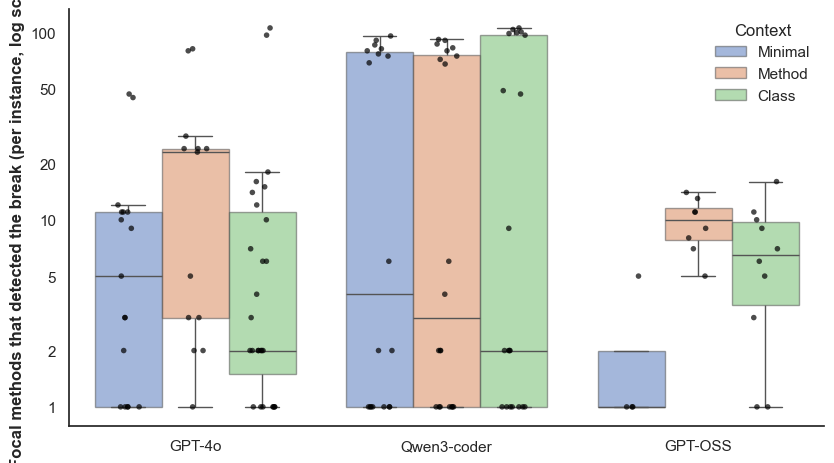

                     count       mean   50%  min    max
GPT-4o      Minimal   17.0  10.235294   5.0  1.0   47.0
            Method    13.0  23.153846  23.0  1.0   82.0
            Class     27.0  12.407407   2.0  1.0  106.0
Qwen3-coder Minimal   18.0  37.388889   4.0  1.0   96.0
            Method    20.0  33.550000   3.0  1.0   92.0
            Class     20.0  36.350000   2.0  1.0  106.0
GPT-OSS     Minimal    4.0   2.000000   1.0  1.0    5.0
            Method     8.0   9.750000  10.0  5.0   14.0
            Class     10.0   6.900000   6.5  1.0   16.0


In [30]:
import json
import glob
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Data: DetectedTestFileCount per (Model, Context, Instance) ──────────────
JSON_DIR = "../CountingNoOfTestCasesToReport/output/DetectedTestCount"

MODEL_DISPLAY = {"GPT4o": "GPT-4o", "Qwen3-coder": "Qwen3-coder", "GPTOSS": "GPT-OSS"}
MODEL_ORDER = ["GPT-4o", "Qwen3-coder", "GPT-OSS"]
CONTEXT_ORDER = ["Minimal", "Method", "Class"]

records = []
for path in glob.glob(f"{JSON_DIR}/*.json"):
    for row in json.load(open(path)):
        records.append(row)

raw = pd.DataFrame(records)
raw["Model"] = raw["Model"].map(MODEL_DISPLAY)
assert raw["Model"].notna().all(), "Unmapped model(s) in DetectedTestCount JSON files"

# Only instances where detection actually succeeded: numeric and > 0
# (excludes "NOT_VALID" = compile/execution failures, and 0 = ran but missed the break)
numeric = pd.to_numeric(raw["DetectedTestFileCount"], errors="coerce")
detected = raw.loc[numeric.notna() & (numeric > 0)].copy()
detected["DetectedTestFileCount"] = numeric.loc[detected.index].astype(int)

detected.to_csv("RQ2_data/figures/rq2_testfile_count_per_instance.csv", index=False)

# Per-instance counts are strongly bimodal/right-skewed (e.g. most instances
# detect with 1-10 test files, a handful detect with 45-106, nothing between)
# — a violin's KDE pinches into a misleading "flute" shape on data like this
# with only 13-27 points per group. A box+strip plot on a log y-axis shows
# every real instance point without inventing a smooth density between them.
sns.set_theme(style="white")
plt.rcParams.update({"font.size": 12, "pdf.fonttype": 42})

fig, ax = plt.subplots(figsize=(8.5, 4.8))
sns.boxplot(
    data=detected, x="Model", y="DetectedTestFileCount", hue="Context",
    order=MODEL_ORDER, hue_order=CONTEXT_ORDER,
    palette="muted", ax=ax, linewidth=1.0, fliersize=0, boxprops=dict(alpha=0.55),
)
sns.stripplot(
    data=detected, x="Model", y="DetectedTestFileCount", hue="Context",
    order=MODEL_ORDER, hue_order=CONTEXT_ORDER,
    dodge=True, ax=ax, size=4, alpha=0.7, legend=False,
    palette={c: "black" for c in CONTEXT_ORDER}, jitter=0.15,
)

ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(mticker.NullFormatter())
ax.set_yticks([1, 2, 5, 10, 20, 50, 100])

ax.set_xlabel("")
ax.set_ylabel("Focal methods that detected the break (per instance, log scale)", fontweight="bold")
# ax.set_title("Distribution of detected test-file count per instance", fontweight="bold", pad=15)
sns.despine(ax=ax)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:3], labels[:3], title="Context", frameon=False, loc="upper right")

plt.tight_layout()
plt.savefig("rq2_testfile_distribution.pdf", format="pdf", bbox_inches="tight", dpi=300)
plt.show()

print(detected.groupby(["Model", "Context"])["DetectedTestFileCount"]
      .describe()[["count", "mean", "50%", "min", "max"]]
      .reindex(pd.MultiIndex.from_product([MODEL_ORDER, CONTEXT_ORDER])))

/Users/rachnaraj/miniforge/envs/dev/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 11.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/rachnaraj/miniforge/envs/dev/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 11.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


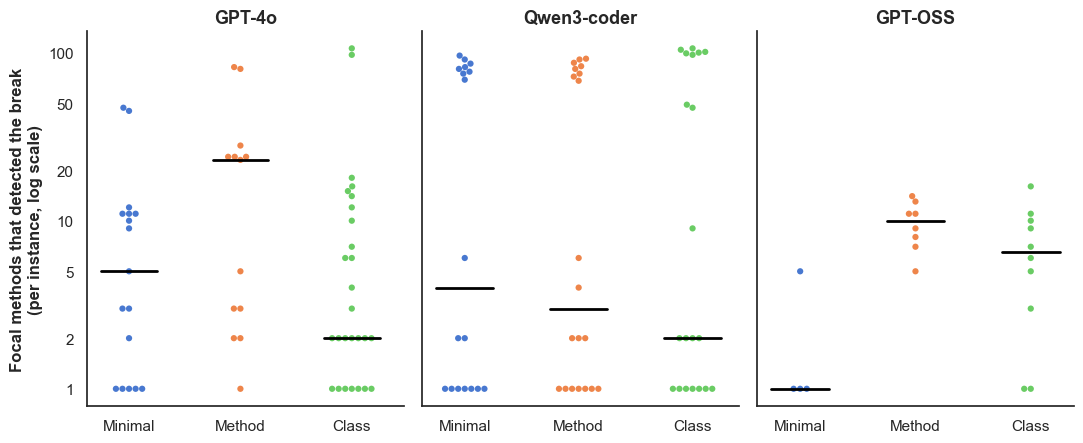

                     count       mean   50%  min    max
GPT-4o      Minimal   17.0  10.235294   5.0  1.0   47.0
            Method    13.0  23.153846  23.0  1.0   82.0
            Class     27.0  12.407407   2.0  1.0  106.0
Qwen3-coder Minimal   18.0  37.388889   4.0  1.0   96.0
            Method    20.0  33.550000   3.0  1.0   92.0
            Class     20.0  36.350000   2.0  1.0  106.0
GPT-OSS     Minimal    4.0   2.000000   1.0  1.0    5.0
            Method     8.0   9.750000  10.0  5.0   14.0
            Class     10.0   6.900000   6.5  1.0   16.0


In [31]:
import json
import glob
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Alternative to the box+strip/log panel above: the dodged boxes got ──────
# cluttered (overlapping legend, giant solid-looking boxes caused by the
# bimodal IQR — most instances detect with 1-10 test files, a handful detect
# with 45-106, nothing in between). This version draws one small-multiple
# panel per model (no dodging, no box fill), a swarm plot per context, and a
# median tick — shows every instance point without a misleading filled box.

JSON_DIR = "../CountingNoOfTestCasesToReport/output/DetectedTestCount"

MODEL_DISPLAY = {"GPT4o": "GPT-4o", "Qwen3-coder": "Qwen3-coder", "GPTOSS": "GPT-OSS"}
MODEL_ORDER = ["GPT-4o", "Qwen3-coder", "GPT-OSS"]
CONTEXT_ORDER = ["Minimal", "Method", "Class"]
Y_TICKS = [1, 2, 5, 10, 20, 50, 100]

records = []
for path in glob.glob(f"{JSON_DIR}/*.json"):
    for row in json.load(open(path)):
        records.append(row)

raw = pd.DataFrame(records)
raw["Model"] = raw["Model"].map(MODEL_DISPLAY)
assert raw["Model"].notna().all(), "Unmapped model(s) in DetectedTestCount JSON files"

# Only instances where detection actually succeeded: numeric and > 0
# (excludes "NOT_VALID" = compile/execution failures, and 0 = ran but missed the break)
numeric = pd.to_numeric(raw["DetectedTestFileCount"], errors="coerce")
detected = raw.loc[numeric.notna() & (numeric > 0)].copy()
detected["DetectedTestFileCount"] = numeric.loc[detected.index].astype(int)

detected.to_csv("RQ2_data/figures/rq2_testfile_swarm_data.csv", index=False)

# ── Plot: one small-multiple panel per model, swarm per context ────────────
sns.set_theme(style="white")
plt.rcParams.update({"font.size": 12, "pdf.fonttype": 42})

fig, axes = plt.subplots(1, 3, figsize=(11, 4.6), sharey=True)

for ax, model in zip(axes, MODEL_ORDER):
    mdf = detected[detected["Model"] == model]
    sns.swarmplot(
        data=mdf, x="Context", y="DetectedTestFileCount",
        order=CONTEXT_ORDER, hue="Context", hue_order=CONTEXT_ORDER,
        palette="muted", ax=ax, size=4.5, legend=False,
    )

    # Median tick per context: short black horizontal bar
    for i, ctx in enumerate(CONTEXT_ORDER):
        vals = mdf.loc[mdf["Context"] == ctx, "DetectedTestFileCount"]
        if len(vals) == 0:
            continue
        median = vals.median()
        ax.plot([i - 0.25, i + 0.25], [median, median], color="black", linewidth=2, zorder=5)

    ax.set_title(model, fontweight="bold", fontsize=13)
    ax.set_xlabel("")
    ax.set_ylabel("")
    sns.despine(ax=ax)

axes[0].set_yscale("log")
axes[0].yaxis.set_major_formatter(mticker.ScalarFormatter())
axes[0].yaxis.set_minor_formatter(mticker.NullFormatter())
axes[0].set_yticks(Y_TICKS)
axes[0].set_ylabel("Focal methods that detected the break\n(per instance, log scale)", fontweight="bold")

# fig.suptitle("Distribution of detected test-file count per instance", fontweight="bold", y=1.02)

plt.tight_layout()
plt.savefig("rq2_testfile_swarm.pdf", format="pdf", bbox_inches="tight", dpi=300)
plt.show()

print(detected.groupby(["Model", "Context"])["DetectedTestFileCount"]
      .describe()[["count", "mean", "50%", "min", "max"]]
      .reindex(pd.MultiIndex.from_product([MODEL_ORDER, CONTEXT_ORDER])))

/var/folders/5j/383lm0896fj7zjtxk6zgp95r0000gs/T/ipykernel_30807/259020226.py:5: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:.25'` for the same effect.

  sns.stripplot(data=detected, x="Model", y="DetectedTestFileCount", hue="Context",


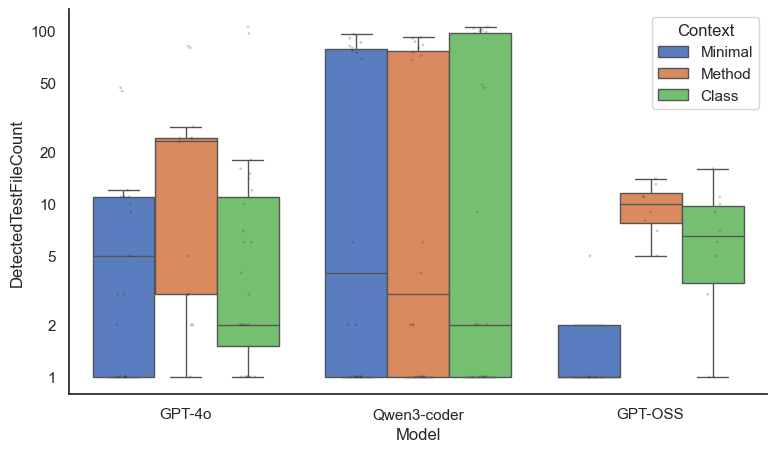

In [32]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=detected, x="Model", y="DetectedTestFileCount", hue="Context",
            order=MODEL_ORDER, hue_order=CONTEXT_ORDER, palette="muted",
            showfliers=False, ax=ax)
sns.stripplot(data=detected, x="Model", y="DetectedTestFileCount", hue="Context",
              order=MODEL_ORDER, hue_order=CONTEXT_ORDER, dodge=True,
              color=".25", size=2, alpha=0.25, ax=ax, legend=False)
ax.set_yscale("log")
ax.set_yticks(Y_TICKS)
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
sns.despine(ax=ax)

/var/folders/5j/383lm0896fj7zjtxk6zgp95r0000gs/T/ipykernel_30807/213382176.py:21: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


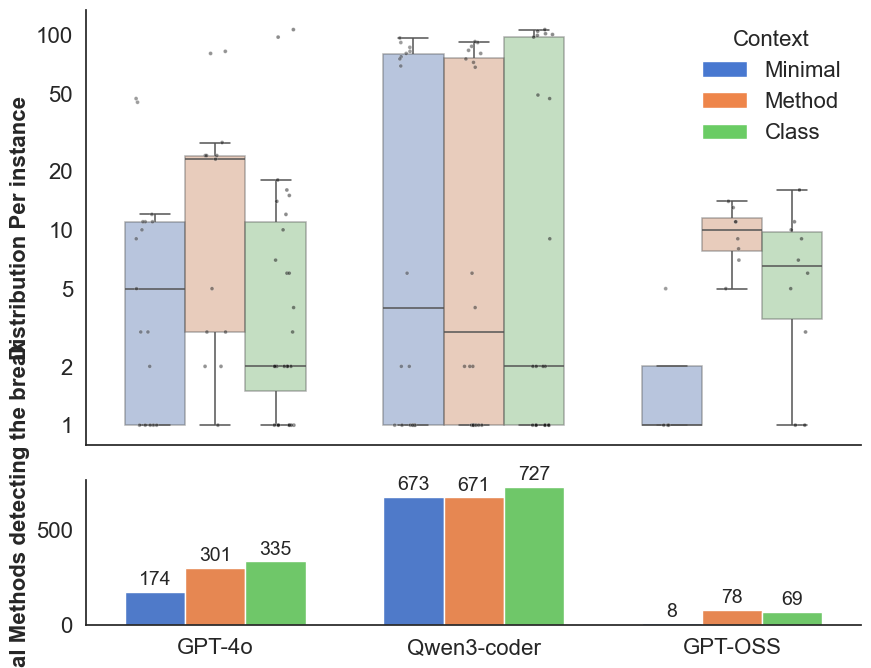

In [33]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

plt.rcParams.update({"font.size": 16, "pdf.fonttype": 42, "font.family": "sans-serif"})

pal = dict(zip(CONTEXT_ORDER, sns.color_palette("muted", len(CONTEXT_ORDER))))

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(10, 7.5), height_ratios=[3, 1], sharex=True
)

# --- Top: per-instance distribution ---
sns.boxplot(
    data=detected, x="Model", y="DetectedTestFileCount", hue="Context",
    order=MODEL_ORDER, hue_order=CONTEXT_ORDER, palette=pal,
    showfliers=False, saturation=0.6, linewidth=1.1, width=0.7,
    boxprops=dict(alpha=0.45), ax=ax_top,
)
sns.stripplot(
    data=detected, x="Model", y="DetectedTestFileCount", hue="Context",
    order=MODEL_ORDER, hue_order=CONTEXT_ORDER, dodge=True,
    color="black", size=2.8, alpha=0.45, jitter=0.12,
    edgecolor="white", linewidth=0.3, ax=ax_top, legend=False,
)
ax_top.set_yscale("log")
ax_top.set_yticks(Y_TICKS)
ax_top.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax_top.set_ylabel("Distribution Per instance", fontweight="bold", fontsize=16)
ax_top.set_xlabel("")
ax_top.tick_params(labelsize=16)

handles = [mpatches.Patch(facecolor=pal[c], label=c) for c in CONTEXT_ORDER]
ax_top.legend(handles=handles, title="Context", frameon=False, loc="upper right",
              fontsize=16, title_fontsize=16)

# --- Bottom: totals ---
sns.barplot(
    data=detected, x="Model", y="DetectedTestFileCount", hue="Context",
    order=MODEL_ORDER, hue_order=CONTEXT_ORDER, palette=pal,
    estimator="sum", errorbar=None, saturation=0.9, width=0.7, ax=ax_bot,
)
ax_bot.legend_.remove()
ax_bot.set_ylabel("Total Focal Methods detecting the break", fontweight="bold", fontsize=16)
ax_bot.set_xlabel("")
ax_bot.tick_params(labelsize=16)
for c in ax_bot.containers:
    ax_bot.bar_label(c, fmt="%d", fontsize=14, padding=2)


sns.despine(fig=fig)
fig.align_ylabels()
plt.subplots_adjust(hspace=0.12, top=0.93)
plt.savefig("rq2_slide.pdf", format="pdf", bbox_inches="tight", dpi=300)

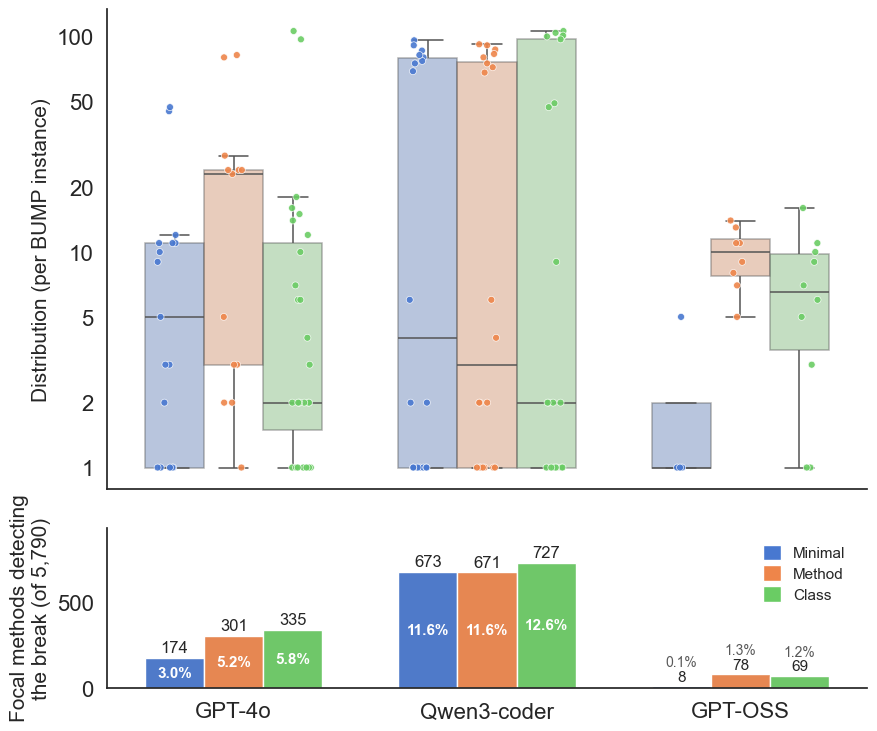

In [34]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

plt.rcParams.update({"font.size": 16, "pdf.fonttype": 42, "font.family": "sans-serif"})

pal = dict(zip(CONTEXT_ORDER, sns.color_palette("muted", len(CONTEXT_ORDER))))

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(10, 7.8), height_ratios=[3, 1], sharex=True
)

# --- Top: per-instance distribution ---
sns.boxplot(
    data=detected, x="Model", y="DetectedTestFileCount", hue="Context",
    order=MODEL_ORDER, hue_order=CONTEXT_ORDER, palette=pal,
    showfliers=False, saturation=0.6, linewidth=1.1, width=0.7,
    boxprops=dict(alpha=0.45), ax=ax_top,
)
sns.stripplot(
    data=detected, x="Model", y="DetectedTestFileCount", hue="Context",
    order=MODEL_ORDER, hue_order=CONTEXT_ORDER, dodge=True,
    palette=pal, size=5, alpha=0.9, jitter=0.12,
    edgecolor="white", linewidth=0.5, ax=ax_top, legend=False,
)
ax_top.set_yscale("log")
ax_top.set_yticks(Y_TICKS)
ax_top.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax_top.set_ylabel("Distribution (per BUMP instance)", fontsize=15)
ax_top.set_xlabel("")
ax_top.tick_params(labelsize=16)
ax_top.get_legend().remove()

# --- Bottom: totals ---
sns.barplot(
    data=detected, x="Model", y="DetectedTestFileCount", hue="Context",
    order=MODEL_ORDER, hue_order=CONTEXT_ORDER, palette=pal,
    estimator="sum", errorbar=None, saturation=0.9, width=0.7, ax=ax_bot,
)
ax_bot.legend_.remove()
ax_bot.set_ylabel("Focal methods detecting\nthe break (of 5,790)", fontsize=15)
ax_bot.set_xlabel("")
ax_bot.tick_params(labelsize=16)

GRAND_TOTAL = 5790
y_top = ax_bot.get_ylim()[1]
for c in ax_bot.containers:
    for bar in c:
        h = bar.get_height()
        x = bar.get_x() + bar.get_width() / 2
        pct = f"{h / GRAND_TOTAL * 100:.1f}%"
        if h > y_top * 0.18:
            ax_bot.text(x, h + y_top * 0.02, f"{int(h)}", ha="center", va="bottom", fontsize=12)
            ax_bot.text(x, h / 2, pct, ha="center", va="center",
                        fontsize=11, color="white", fontweight="bold")
        else:
            ax_bot.text(x, h + y_top * 0.02, f"{int(h)}", ha="center", va="bottom", fontsize=11)
            ax_bot.text(x, h + y_top * 0.13, pct, ha="center", va="bottom",
                        fontsize=10, color="0.35")

ax_bot.set_ylim(top=y_top * 1.22)

# --- Small vertical legend inside the bottom plot, above GPT-OSS ---
handles = [mpatches.Patch(facecolor=pal[c], label=c) for c in CONTEXT_ORDER]
ax_bot.legend(handles=handles, frameon=False,
              loc="upper right", bbox_to_anchor=(0.99, 0.98),
              ncol=1, fontsize=11, handlelength=1.2, handleheight=1.2,
              labelspacing=0.3)

sns.despine(fig=fig)
fig.align_ylabels()
plt.subplots_adjust(hspace=0.12, top=0.97, left=0.14, bottom=0.10)
plt.savefig("rq2_paper.pdf", format="pdf", bbox_inches="tight", dpi=300)

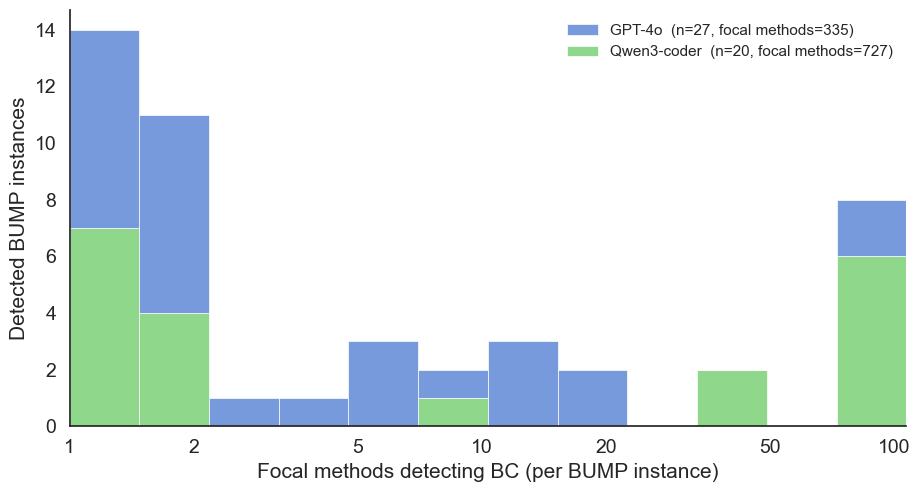

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams.update({"font.size": 16, "pdf.fonttype": 42, "font.family": "sans-serif"})

PAIR_ORDER = ["GPT-4o", "Qwen3-coder"]          # must match detected["Model"] values
muted = sns.color_palette("muted")
pair_pal = {"GPT-4o": muted[0], "Qwen3-coder": muted[2]}

sub = detected[
    (detected["Context"] == "Class")
    & (detected["Model"].isin(PAIR_ORDER))
].copy()

# Log-spaced, contiguous bins → distribution shape across 1..100+
vmax = sub["DetectedTestFileCount"].max()
bins = np.logspace(0, np.log10(vmax + 1), 13)   # 12 bars; raise to 16 for finer, lower for chunkier

fig, ax = plt.subplots(figsize=(9.5, 5.2))
sns.histplot(
    data=sub, x="DetectedTestFileCount", hue="Model",
    hue_order=PAIR_ORDER, palette=pair_pal,
    bins=bins, multiple="stack",
    edgecolor="white", linewidth=0.5, ax=ax,
)

ax.set_xscale("log")
ax.set_xticks([1, 2, 5, 10, 20, 50, 100])
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xlim(bins[0], bins[-1])
ax.set_xlabel("Focal methods detecting BC (per BUMP instance)", fontsize=15)
ax.set_ylabel("Detected BUMP instances", fontsize=15)
ax.tick_params(labelsize=14)

legend = ax.get_legend()
for txt, m in zip(legend.get_texts(), PAIR_ORDER):
    n_inst = (sub["Model"] == m).sum()
    total  = int(sub.loc[sub["Model"] == m, "DetectedTestFileCount"].sum())
    txt.set_text(f"{m}  (n={n_inst}, focal methods={total})")
legend.set_title("")
legend.set_frame_on(False)

sns.despine(fig=fig)
plt.tight_layout()
plt.savefig("rq2_class_distribution.pdf", format="pdf", bbox_inches="tight", dpi=300)

GPT-4o (n=27): [1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 3, 4, 6, 6, 7, 10, 12, 14, 15, 16, 18, 97, 106]
Qwen3-coder (n=20): [1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 9, 47, 49, 97, 99, 100, 101, 104, 106]


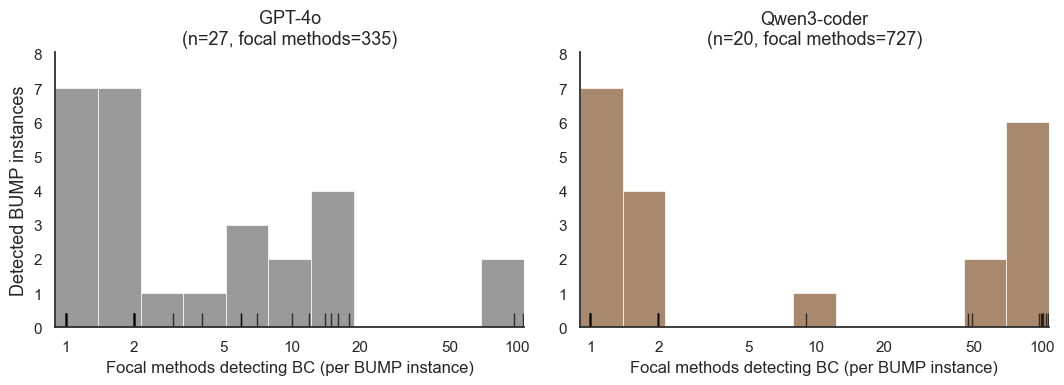

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams.update({"font.size": 18, "pdf.fonttype": 42, "font.family": "sans-serif"})

PAIR_ORDER = ["GPT-4o", "Qwen3-coder"]          # must match detected["Model"] values
muted = sns.color_palette("muted")
pair_pal = {"GPT-4o": muted[7], "Qwen3-coder": muted[5]}   # grey / brown

sub = detected[
    (detected["Context"] == "Class")
    & (detected["Model"].isin(PAIR_ORDER))
].copy()

# --- Diagnostics: full value list per model ---
for m in PAIR_ORDER:
    v = sorted(sub[sub["Model"] == m]["DetectedTestFileCount"].tolist())
    print(f"{m} (n={len(v)}): {v}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))   # NOTE: no sharex / sharey

for ax, m in zip(axes, PAIR_ORDER):
    d = sub[sub["Model"] == m]
    v = d["DetectedTestFileCount"]

    # Per-model bins: span each model's own range, edge just below its min
    lo = max(v.min() * 0.9, 0.9)
    hi = v.max() + 1
    bins = np.logspace(np.log10(lo), np.log10(hi), 12)

    sns.histplot(
        data=d, x="DetectedTestFileCount",
        bins=bins, color=pair_pal[m],
        edgecolor="white", linewidth=0.5, ax=ax,
    )
    sns.rugplot(
        data=d, x="DetectedTestFileCount",
        color="black", height=0.05, linewidth=1.0, alpha=0.7, ax=ax,
    )

    n_inst = len(d)
    total  = int(v.sum())
    ax.set_title(f"{m}\n(n={n_inst}, focal methods={total})", fontsize=13)
    ax.set_xscale("log")

    # Ticks limited to this model's range so labels aren't wasted on empty space
    candidate_ticks = [1, 2, 5, 10, 20, 50, 100]
    ticks = [t for t in candidate_ticks if lo <= t <= hi]
    ax.set_xticks(ticks)
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.set_xlim(bins[0], bins[-1])
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.set_xlabel("Focal methods detecting BC (per BUMP instance)", fontsize=12)
    ax.set_ylabel("")

axes[0].set_ylabel("Detected BUMP instances", fontsize=13)
# fig.suptitle("Distribution of focal-method counts — Class context", fontsize=14, y=1.02)

sns.despine(fig=fig)
plt.tight_layout()
plt.savefig("rq2_class_distribution_panels.pdf", format="pdf", bbox_inches="tight", dpi=300)

/var/folders/5j/383lm0896fj7zjtxk6zgp95r0000gs/T/ipykernel_30807/1716517202.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_bot.set_xticklabels(DISPLAY_LABELS)   # show nicer names without breaking data match


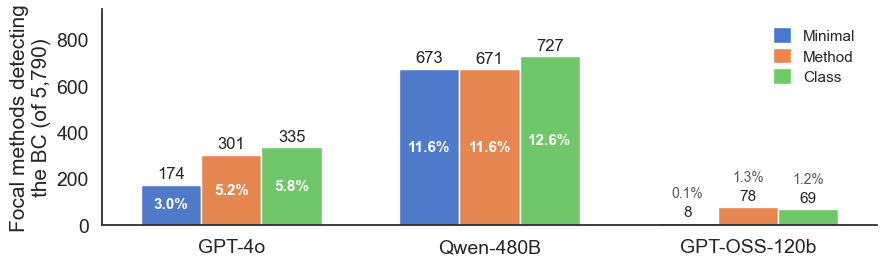

In [37]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

plt.rcParams.update({"font.size": 16, "pdf.fonttype": 42, "font.family": "sans-serif"})

# Must match the exact strings in detected["Model"]. Run:
#   print(sorted(detected["Model"].unique()))
MODEL_ORDER = ["GPT-4o", "Qwen3-coder", "GPT-OSS"]
DISPLAY_LABELS = ["GPT-4o", "Qwen-480B", "GPT-OSS-120b"]   # nicer axis labels

pal = dict(zip(CONTEXT_ORDER, sns.color_palette("muted", len(CONTEXT_ORDER))))

fig, ax_bot = plt.subplots(figsize=(10, 2.8))

sns.barplot(
    data=detected, x="Model", y="DetectedTestFileCount", hue="Context",
    order=MODEL_ORDER, hue_order=CONTEXT_ORDER, palette=pal,
    estimator="sum", errorbar=None, saturation=0.9, width=0.7, ax=ax_bot,
)
ax_bot.legend_.remove()
ax_bot.set_ylabel("Focal methods detecting\nthe BC (of 5,790)", fontsize=15)
ax_bot.set_xlabel("")
ax_bot.tick_params(labelsize=14)
ax_bot.set_xticklabels(DISPLAY_LABELS)   # show nicer names without breaking data match

GRAND_TOTAL = 5790
y_top = ax_bot.get_ylim()[1]
for c in ax_bot.containers:
    for bar in c:
        h = bar.get_height()
        x = bar.get_x() + bar.get_width() / 2
        pct = f"{h / GRAND_TOTAL * 100:.1f}%"
        if h > y_top * 0.18:
            ax_bot.text(x, h + y_top * 0.02, f"{int(h)}", ha="center", va="bottom", fontsize=12)
            ax_bot.text(x, h / 2, pct, ha="center", va="center",
                        fontsize=11, color="white", fontweight="bold")
        else:
            ax_bot.text(x, h + y_top * 0.02, f"{int(h)}", ha="center", va="bottom", fontsize=11)
            ax_bot.text(x, h + y_top * 0.13, pct, ha="center", va="bottom",
                        fontsize=10, color="0.35")

ax_bot.set_ylim(top=y_top * 1.22)

# --- Small vertical legend inside the plot, above GPT-OSS ---
handles = [mpatches.Patch(facecolor=pal[c], label=c) for c in CONTEXT_ORDER]
ax_bot.legend(handles=handles, frameon=False,
              loc="upper right", bbox_to_anchor=(0.99, 0.98),
              ncol=1, fontsize=11, handlelength=1.2, handleheight=1.2,
              labelspacing=0.3)

sns.despine(fig=fig)
plt.savefig("rq2_bottom_only.pdf", format="pdf", bbox_inches="tight", dpi=300)

Same as `rq2_bottom_only.pdf`, but at test-case level

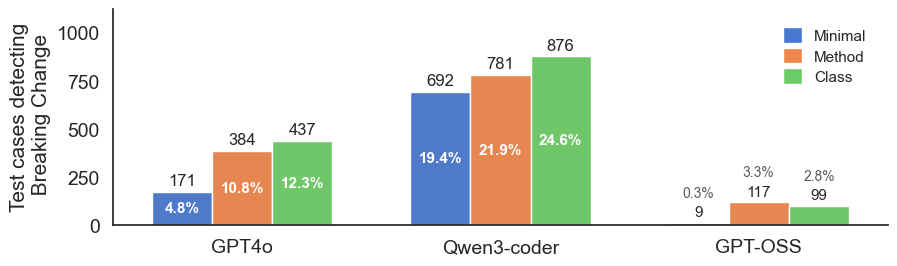

GPT-4o       Minimal    171
             Method     384
             Class      437
Qwen3-coder  Minimal    692
             Method     781
             Class      876
GPT-OSS      Minimal      9
             Method     117
             Class       99


In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

plt.rcParams.update({"font.size": 18, "pdf.fonttype": 42, "font.family": "sans-serif"})

MODEL_ORDER = ["GPT-4o", "Qwen3-coder", "GPT-OSS"]
DISPLAY_LABELS = ["GPT4o", "Qwen3-coder", "GPT-OSS"]   # nicer axis labels
CONTEXT_ORDER = ["Minimal", "Method", "Class"]

# Test-case counts (crash_tests + assert_tests) per Model x Context, from
# RQ3-OracleTypeAndStats/RQ3-table1.ipynb -- test-case level, not test-file level.
RQ3_TABLE1 = "../CountingNoOfTestCasesToReport/RQ3-OracleTypeAndStats/output/success_cases/RQ3-table1.csv"
tests_per_group = pd.read_csv(RQ3_TABLE1)
tests_per_group = tests_per_group[tests_per_group["model"] != "Total"].copy()
tests_per_group["TestCaseCount"] = tests_per_group["crash_tests"] + tests_per_group["assert_tests"]
tests_per_group = tests_per_group.rename(columns={"model": "Model", "context": "Context"})

GRAND_TOTAL_CASES = int(tests_per_group["TestCaseCount"].sum())

pal = dict(zip(CONTEXT_ORDER, sns.color_palette("muted", len(CONTEXT_ORDER))))

fig, ax_bot = plt.subplots(figsize=(10, 2.8))

sns.barplot(
    data=tests_per_group, x="Model", y="TestCaseCount", hue="Context",
    order=MODEL_ORDER, hue_order=CONTEXT_ORDER, palette=pal,
    estimator="sum", errorbar=None, saturation=0.9, width=0.7, ax=ax_bot,
)
ax_bot.legend_.remove()
ax_bot.set_ylabel(f"Test cases detecting\n Breaking Change", fontsize=15)
ax_bot.set_xlabel("")
ax_bot.tick_params(labelsize=14)
ax_bot.set_xticks(range(len(MODEL_ORDER)))
ax_bot.set_xticklabels(DISPLAY_LABELS)

y_top = ax_bot.get_ylim()[1]
for c in ax_bot.containers:
    for bar in c:
        h = bar.get_height()
        x = bar.get_x() + bar.get_width() / 2
        pct = f"{h / GRAND_TOTAL_CASES * 100:.1f}%"
        if h > y_top * 0.18:
            ax_bot.text(x, h + y_top * 0.02, f"{int(h)}", ha="center", va="bottom", fontsize=12)
            ax_bot.text(x, h / 2, pct, ha="center", va="center",
                        fontsize=11, color="white", fontweight="bold")
        else:
            ax_bot.text(x, h + y_top * 0.02, f"{int(h)}", ha="center", va="bottom", fontsize=11)
            ax_bot.text(x, h + y_top * 0.13, pct, ha="center", va="bottom",
                        fontsize=10, color="0.35")

ax_bot.set_ylim(top=y_top * 1.22)

handles = [mpatches.Patch(facecolor=pal[c], label=c) for c in CONTEXT_ORDER]
ax_bot.legend(handles=handles, frameon=False,
              loc="upper right", bbox_to_anchor=(0.99, 0.98),
              ncol=1, fontsize=11, handlelength=1.2, handleheight=1.2,
              labelspacing=0.3)

sns.despine(fig=fig)
plt.savefig("rq2_bottom_only_testcase.pdf", format="pdf", bbox_inches="tight", dpi=300)
plt.show()

print(tests_per_group.set_index(["Model", "Context"])["TestCaseCount"]
      .reindex(pd.MultiIndex.from_product([MODEL_ORDER, CONTEXT_ORDER])).to_string())

GPT-4o (n=27): [1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 3, 4, 6, 6, 7, 10, 12, 14, 15, 16, 18, 97, 106]
Qwen3-coder (n=20): [1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 9, 47, 49, 97, 99, 100, 101, 104, 106]


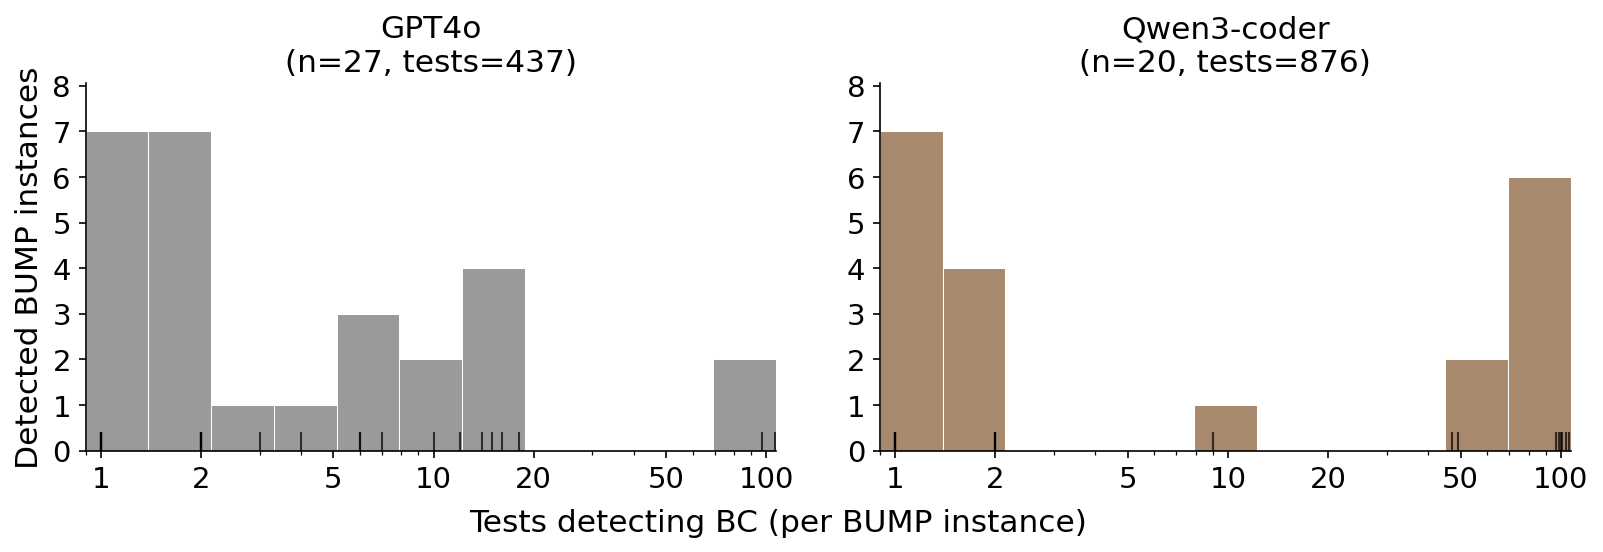

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams.update({"font.size": 20, "pdf.fonttype": 42, "font.family": "sans-serif"})

PAIR_ORDER = ["GPT-4o", "Qwen3-coder"]          # must match detected["Model"] values
DISPLAY_NAME = {"GPT-4o": "GPT4o", "Qwen3-coder": "Qwen3-coder", "GPT-OSS": "GPT-OSS"}
TEST_TOTALS = {"GPT-4o": 437, "Qwen3-coder": 876}
muted = sns.color_palette("muted")
pair_pal = {"GPT-4o": muted[7], "Qwen3-coder": muted[5]}   # grey / brown

sub = detected[
    (detected["Context"] == "Class")
    & (detected["Model"].isin(PAIR_ORDER))
].copy()

# --- Diagnostics: full value list per model ---
for m in PAIR_ORDER:
    v = sorted(sub[sub["Model"] == m]["DetectedTestFileCount"].tolist())
    print(f"{m} (n={len(v)}): {v}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))   # shorter; no sharex / sharey

for ax, m in zip(axes, PAIR_ORDER):
    d = sub[sub["Model"] == m]
    v = d["DetectedTestFileCount"]

    # Per-model bins: span each model's own range, edge just below its min
    lo = max(v.min() * 0.9, 0.9)
    hi = v.max() + 1
    bins = np.logspace(np.log10(lo), np.log10(hi), 12)

    sns.histplot(
        data=d, x="DetectedTestFileCount",
        bins=bins, color=pair_pal[m],
        edgecolor="white", linewidth=0.5, ax=ax,
    )
    sns.rugplot(
        data=d, x="DetectedTestFileCount",
        color="black", height=0.05, linewidth=1.0, alpha=0.7, ax=ax,
    )

    n_inst = len(d)
    total = TEST_TOTALS[m]
    ax.set_title(f"{DISPLAY_NAME[m]}\n(n={n_inst}, tests={total})", fontsize=15)
    ax.set_xscale("log")

    # Ticks limited to this model's range so labels aren't wasted on empty space
    candidate_ticks = [1, 2, 5, 10, 20, 50, 100]
    ticks = [t for t in candidate_ticks if lo <= t <= hi]
    ax.set_xticks(ticks)
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.set_xlim(bins[0], bins[-1])
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(labelsize=14)

axes[0].set_ylabel("Detected BUMP instances", fontsize=15)
fig.supxlabel("Tests detecting BC (per BUMP instance)", fontsize=15, y=0.02)
# fig.suptitle("Distribution of focal-method counts — Class context", fontsize=14, y=1.02)

sns.despine(fig=fig)
plt.subplots_adjust(bottom=0.18, top=0.86, left=0.08, right=0.98, wspace=0.15)
plt.savefig("rq2_class_distribution_panels.pdf", format="pdf", dpi=300)

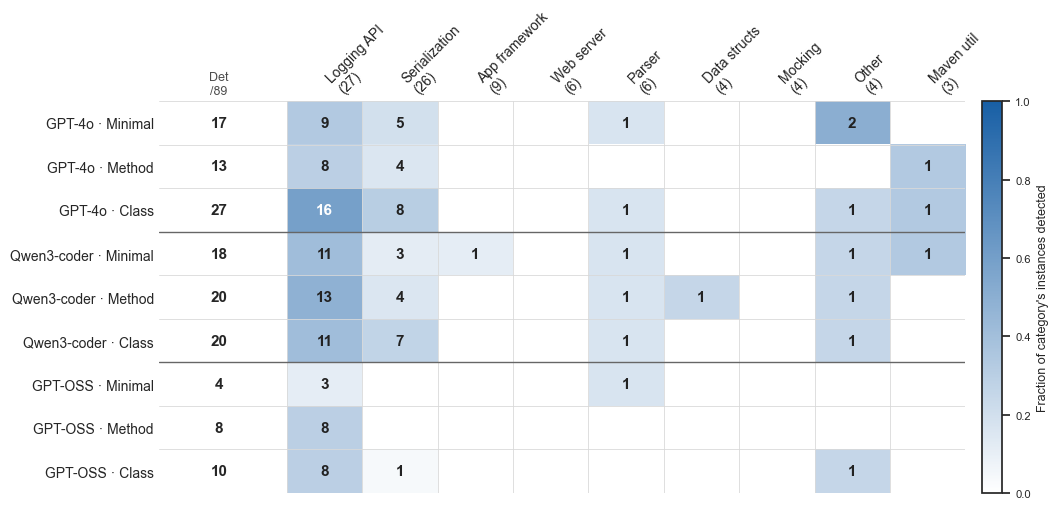

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ── Data from Table VI ───────────────────────────────────────────────────────
# categories ordered by total instances (desc); (total) shown in header
categories = [
    ("Logging API", 27), ("Serialization", 26), ("App framework", 9),
    ("Web server", 6), ("Parser", 6), ("Data structs", 4),
    ("Mocking", 4), ("Other", 4), ("Maven util", 3),
]
# rows: (model, context)
row_labels = [
    ("GPT-4o", "Minimal"), ("GPT-4o", "Method"), ("GPT-4o", "Class"),
    ("Qwen3-coder", "Minimal"), ("Qwen3-coder", "Method"), ("Qwen3-coder", "Class"),
    ("GPT-OSS", "Minimal"), ("GPT-OSS", "Method"), ("GPT-OSS", "Class"),
]
# detected counts, rows × categories (order matches above). 0 = none
counts = np.array([
    [ 9, 5, 0, 0, 1, 0, 0, 2, 0],   # GPT-4o Minimal
    [ 8, 4, 0, 0, 0, 0, 0, 0, 1],   # GPT-4o Method
    [16, 8, 0, 0, 1, 0, 0, 1, 1],   # GPT-4o Class
    [11, 3, 1, 0, 1, 0, 0, 1, 1],   # Qwen Minimal
    [13, 4, 0, 0, 1, 1, 0, 1, 0],   # Qwen Method
    [11, 7, 0, 0, 1, 0, 0, 1, 0],   # Qwen Class
    [ 3, 0, 0, 0, 1, 0, 0, 0, 0],   # OSS Minimal
    [ 8, 0, 0, 0, 0, 0, 0, 0, 0],   # OSS Method
    [ 8, 1, 0, 0, 0, 0, 0, 1, 0],   # OSS Class
])
det_totals = [17, 13, 27, 18, 20, 20, 4, 8, 10]  # "Det" column (of 89)
N_TOTAL = 89

totals = np.array([c[1] for c in categories])
frac = counts / totals  # within-category fraction, 0..1

# ── Colormap: white → deep blue ─────────────────────────────────────────────
cmap = LinearSegmentedColormap.from_list("bluefill", ["#ffffff", "#185FA5"])

n_rows, n_cols = counts.shape
fig, ax = plt.subplots(figsize=(11, 5.5))

# draw the fraction heatmap; separate "Det" column drawn to the left
im = ax.imshow(frac, cmap=cmap, vmin=0, vmax=1, aspect="auto")

# cell text: count (blank if zero), white on dark cells
for i in range(n_rows):
    for j in range(n_cols):
        v = counts[i, j]
        if v == 0:
            continue
        txtcol = "white" if frac[i, j] > 0.5 else "#222"
        ax.text(j, i, str(v), ha="center", va="center",
                fontsize=11, color=txtcol, fontweight="bold")

# ── Axes / headers ──────────────────────────────────────────────────────────
ax.set_xticks(range(n_cols))
ax.set_xticklabels([f"{name}\n({tot})" for name, tot in categories],
                   fontsize=10, rotation=45, ha="left")
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")

ax.set_yticks(range(n_rows))
ax.set_yticklabels([f"{m} · {c}" for m, c in row_labels], fontsize=10)

# faint grid lines between cells
ax.set_xticks(np.arange(-.5, n_cols, 1), minor=True)
ax.set_yticks(np.arange(-.5, n_rows, 1), minor=True)
ax.grid(which="minor", color="0.85", linewidth=0.6)
ax.tick_params(which="both", length=0)

# "Det (of 89)" annotations just left of the grid
for i, d in enumerate(det_totals):
    ax.text(-1.4, i, f"{d}", ha="center", va="center", fontsize=11, fontweight="bold")
ax.text(-1.4, -0.9, "Det\n/89", ha="center", va="center", fontsize=9, color="0.3")

# thin separators between model groups
for yy in (2.5, 5.5):
    ax.axhline(yy, color="0.4", linewidth=1.0)

ax.set_xlim(-2.2, n_cols - 0.5)

# colorbar for the fraction scale
cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("Fraction of category's instances detected", fontsize=9)
cbar.ax.tick_params(labelsize=8)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig("rq2_breadth_heatmap.pdf", format="pdf", bbox_inches="tight", dpi=300)
plt.show()

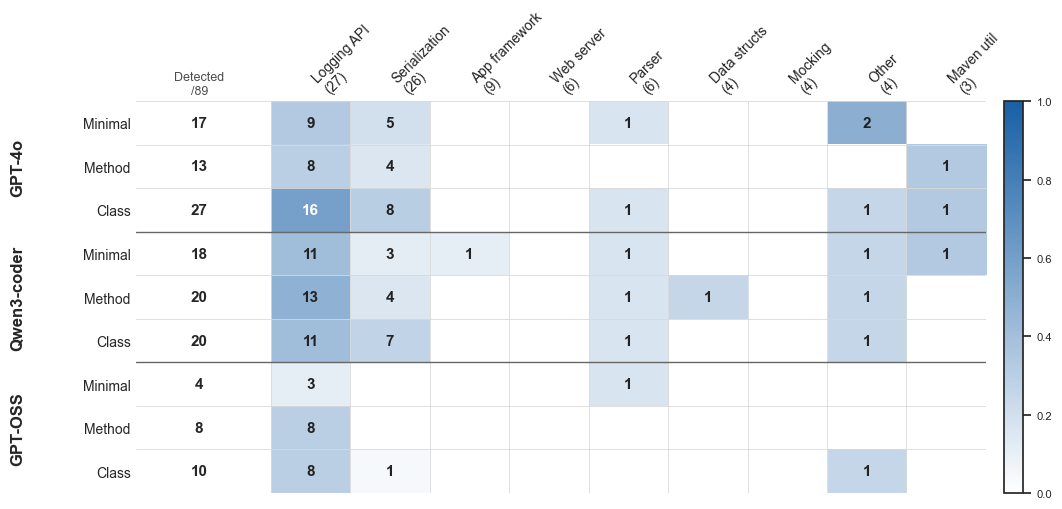

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

categories = [
    ("Logging API", 27), ("Serialization", 26), ("App framework", 9),
    ("Web server", 6), ("Parser", 6), ("Data structs", 4),
    ("Mocking", 4), ("Other", 4), ("Maven util", 3),
]
MODEL_ORDER = ["GPT-4o", "Qwen3-coder", "GPT-OSS"]
CONTEXT_ORDER = ["Minimal", "Method", "Class"]
row_labels = [(m, c) for m in MODEL_ORDER for c in CONTEXT_ORDER]

counts = np.array([
    [ 9, 5, 0, 0, 1, 0, 0, 2, 0],
    [ 8, 4, 0, 0, 0, 0, 0, 0, 1],
    [16, 8, 0, 0, 1, 0, 0, 1, 1],
    [11, 3, 1, 0, 1, 0, 0, 1, 1],
    [13, 4, 0, 0, 1, 1, 0, 1, 0],
    [11, 7, 0, 0, 1, 0, 0, 1, 0],
    [ 3, 0, 0, 0, 1, 0, 0, 0, 0],
    [ 8, 0, 0, 0, 0, 0, 0, 0, 0],
    [ 8, 1, 0, 0, 0, 0, 0, 1, 0],
])
det_totals = [17, 13, 27, 18, 20, 20, 4, 8, 10]
N_TOTAL = 89

totals = np.array([c[1] for c in categories])
frac = counts / totals
cmap = LinearSegmentedColormap.from_list("bluefill", ["#ffffff", "#185FA5"])

n_rows, n_cols = counts.shape
fig, ax = plt.subplots(figsize=(11, 5.5))
im = ax.imshow(frac, cmap=cmap, vmin=0, vmax=1, aspect="auto")

for i in range(n_rows):
    for j in range(n_cols):
        v = counts[i, j]
        if v == 0:
            continue
        txtcol = "white" if frac[i, j] > 0.5 else "#222"
        ax.text(j, i, str(v), ha="center", va="center",
                fontsize=11, color=txtcol, fontweight="bold")

# x headers
ax.set_xticks(range(n_cols))
ax.set_xticklabels([f"{name}\n({tot})" for name, tot in categories],
                   fontsize=10, rotation=45, ha="left")
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")

# y: context only on ticks; model name once, vertical, per group
ax.set_yticks(range(n_rows))
ax.set_yticklabels([c for _, c in row_labels], fontsize=10)

model_spans = {}
for idx, (m, c) in enumerate(row_labels):
    model_spans.setdefault(m, [idx, idx])
    model_spans[m][1] = idx
for m, (s, e) in model_spans.items():
    center = (s + e) / 2
    ax.text(-0.13, center, m, transform=ax.get_yaxis_transform(),
            ha="right", va="center", fontweight="bold", fontsize=12, rotation=90)

# grid
ax.set_xticks(np.arange(-.5, n_cols, 1), minor=True)
ax.set_yticks(np.arange(-.5, n_rows, 1), minor=True)
ax.grid(which="minor", color="0.85", linewidth=0.6)
ax.tick_params(which="both", length=0)

# Det column
for i, d in enumerate(det_totals):
    ax.text(-1.4, i, f"{d}", ha="center", va="center", fontsize=11, fontweight="bold")
ax.text(-1.4, -0.9, "Detected\n/89", ha="center", va="center", fontsize=9, color="0.3")

for yy in (2.5, 5.5):
    ax.axhline(yy, color="0.4", linewidth=1.0)

ax.set_xlim(-2.2, n_cols - 0.5)

cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
# cbar.set_label("Fraction of category's instances detected", fontsize=9)
cbar.ax.tick_params(labelsize=8)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig("rq2_breadth_heatmap.pdf", format="pdf", bbox_inches="tight", dpi=300)
plt.show()

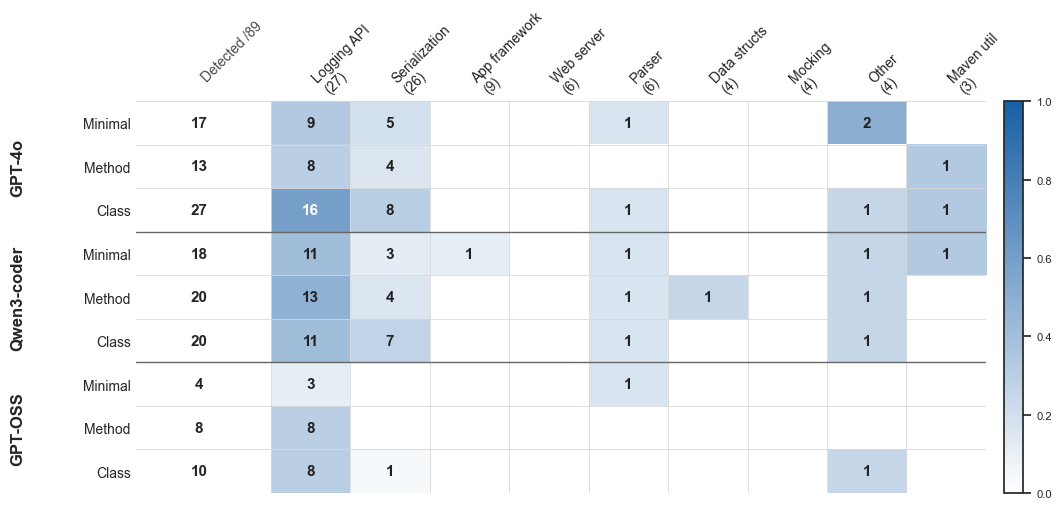

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

categories = [
    ("Logging API", 27), ("Serialization", 26), ("App framework", 9),
    ("Web server", 6), ("Parser", 6), ("Data structs", 4),
    ("Mocking", 4), ("Other", 4), ("Maven util", 3),
]
MODEL_ORDER = ["GPT-4o", "Qwen3-coder", "GPT-OSS"]
CONTEXT_ORDER = ["Minimal", "Method", "Class"]
row_labels = [(m, c) for m in MODEL_ORDER for c in CONTEXT_ORDER]

counts = np.array([
    [ 9, 5, 0, 0, 1, 0, 0, 2, 0],
    [ 8, 4, 0, 0, 0, 0, 0, 0, 1],
    [16, 8, 0, 0, 1, 0, 0, 1, 1],
    [11, 3, 1, 0, 1, 0, 0, 1, 1],
    [13, 4, 0, 0, 1, 1, 0, 1, 0],
    [11, 7, 0, 0, 1, 0, 0, 1, 0],
    [ 3, 0, 0, 0, 1, 0, 0, 0, 0],
    [ 8, 0, 0, 0, 0, 0, 0, 0, 0],
    [ 8, 1, 0, 0, 0, 0, 0, 1, 0],
])
det_totals = [17, 13, 27, 18, 20, 20, 4, 8, 10]
N_TOTAL = 89

totals = np.array([c[1] for c in categories])
frac = counts / totals
cmap = LinearSegmentedColormap.from_list("bluefill", ["#ffffff", "#185FA5"])

n_rows, n_cols = counts.shape
fig, ax = plt.subplots(figsize=(11, 5.5))
im = ax.imshow(frac, cmap=cmap, vmin=0, vmax=1, aspect="auto")

for i in range(n_rows):
    for j in range(n_cols):
        v = counts[i, j]
        if v == 0:
            continue
        txtcol = "white" if frac[i, j] > 0.5 else "#222"
        ax.text(j, i, str(v), ha="center", va="center",
                fontsize=11, color=txtcol, fontweight="bold")

# x headers
ax.set_xticks(range(n_cols))
ax.set_xticklabels([f"{name}\n({tot})" for name, tot in categories],
                   fontsize=10, rotation=45, ha="left")
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")

# y: context only on ticks; model name once, vertical, per group
ax.set_yticks(range(n_rows))
ax.set_yticklabels([c for _, c in row_labels], fontsize=10)

model_spans = {}
for idx, (m, c) in enumerate(row_labels):
    model_spans.setdefault(m, [idx, idx])
    model_spans[m][1] = idx
for m, (s, e) in model_spans.items():
    center = (s + e) / 2
    ax.text(-0.13, center, m, transform=ax.get_yaxis_transform(),
            ha="right", va="center", fontweight="bold", fontsize=12, rotation=90)

# grid
ax.set_xticks(np.arange(-.5, n_cols, 1), minor=True)
ax.set_yticks(np.arange(-.5, n_rows, 1), minor=True)
ax.grid(which="minor", color="0.85", linewidth=0.6)
ax.tick_params(which="both", length=0)

# Det column
for i, d in enumerate(det_totals):
    ax.text(-1.4, i, f"{d}", ha="center", va="center", fontsize=11, fontweight="bold")
ax.text(-1.4, -0.9, "Detected /89", rotation=45, ha="left", va="bottom",
        fontsize=10, color="0.3")

for yy in (2.5, 5.5):
    ax.axhline(yy, color="0.4", linewidth=1.0)

ax.set_xlim(-2.2, n_cols - 0.5)

cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.ax.tick_params(labelsize=8)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig("rq2_breadth_heatmap.pdf", format="pdf", bbox_inches="tight", dpi=300)
plt.show()

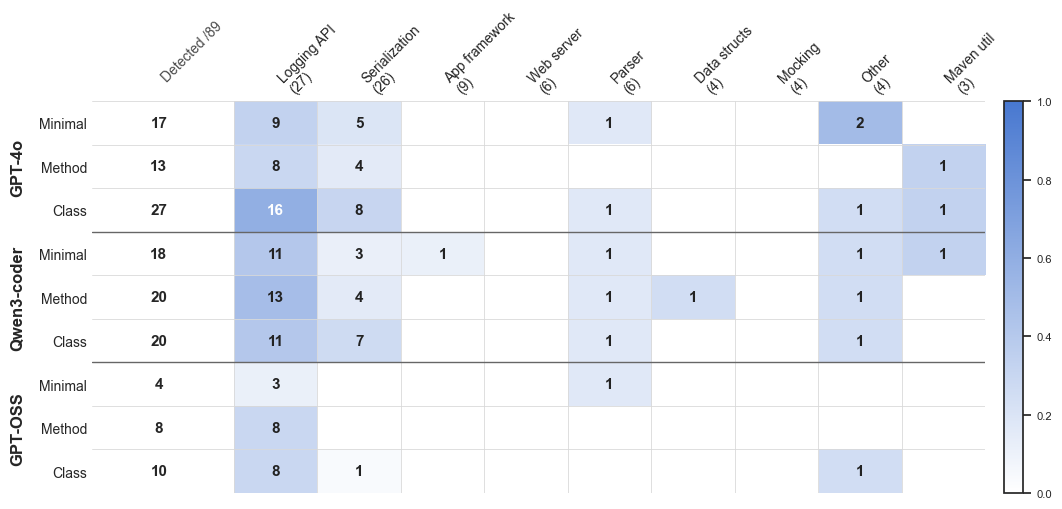

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

categories = [
    ("Logging API", 27), ("Serialization", 26), ("App framework", 9),
    ("Web server", 6), ("Parser", 6), ("Data structs", 4),
    ("Mocking", 4), ("Other", 4), ("Maven util", 3),
]
MODEL_ORDER = ["GPT-4o", "Qwen3-coder", "GPT-OSS"]
CONTEXT_ORDER = ["Minimal", "Method", "Class"]
row_labels = [(m, c) for m in MODEL_ORDER for c in CONTEXT_ORDER]

counts = np.array([
    [ 9, 5, 0, 0, 1, 0, 0, 2, 0],
    [ 8, 4, 0, 0, 0, 0, 0, 0, 1],
    [16, 8, 0, 0, 1, 0, 0, 1, 1],
    [11, 3, 1, 0, 1, 0, 0, 1, 1],
    [13, 4, 0, 0, 1, 1, 0, 1, 0],
    [11, 7, 0, 0, 1, 0, 0, 1, 0],
    [ 3, 0, 0, 0, 1, 0, 0, 0, 0],
    [ 8, 0, 0, 0, 0, 0, 0, 0, 0],
    [ 8, 1, 0, 0, 0, 0, 0, 1, 0],
])
det_totals = [17, 13, 27, 18, 20, 20, 4, 8, 10]
N_TOTAL = 89

totals = np.array([c[1] for c in categories])
frac = counts / totals

# match the "muted" blue used for the Minimal context in the bar plots
muted_blue = sns.color_palette("muted")[0]
cmap = LinearSegmentedColormap.from_list("mutedblue", ["#ffffff", muted_blue])

n_rows, n_cols = counts.shape
fig, ax = plt.subplots(figsize=(11, 5.5))
im = ax.imshow(frac, cmap=cmap, vmin=0, vmax=1, aspect="auto")

for i in range(n_rows):
    for j in range(n_cols):
        v = counts[i, j]
        if v == 0:
            continue
        txtcol = "white" if frac[i, j] > 0.5 else "#222"
        ax.text(j, i, str(v), ha="center", va="center",
                fontsize=11, color=txtcol, fontweight="bold")

# x headers
ax.set_xticks(range(n_cols))
ax.set_xticklabels([f"{name}\n({tot})" for name, tot in categories],
                   fontsize=10, rotation=45, ha="left")
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")

# y: context only on ticks; model name once, vertical, per group
ax.set_yticks(range(n_rows))
ax.set_yticklabels([c for _, c in row_labels], fontsize=10)

model_spans = {}
for idx, (m, c) in enumerate(row_labels):
    model_spans.setdefault(m, [idx, idx])
    model_spans[m][1] = idx
for m, (s, e) in model_spans.items():
    center = (s + e) / 2
    ax.text(-0.075, center, m, transform=ax.get_yaxis_transform(),
            ha="right", va="center", fontweight="bold", fontsize=12, rotation=90)

# grid
ax.set_xticks(np.arange(-.5, n_cols, 1), minor=True)
ax.set_yticks(np.arange(-.5, n_rows, 1), minor=True)
ax.grid(which="minor", color="0.85", linewidth=0.6)
ax.tick_params(which="both", length=0)

# Det column
for i, d in enumerate(det_totals):
    ax.text(-1.4, i, f"{d}", ha="center", va="center", fontsize=11, fontweight="bold")
ax.text(-1.4, -0.9, "Detected /89", rotation=45, ha="left", va="bottom",
        fontsize=10, color="0.3")

for yy in (2.5, 5.5):
    ax.axhline(yy, color="0.4", linewidth=1.0)

ax.set_xlim(-2.2, n_cols - 0.5)

cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.ax.tick_params(labelsize=8)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig("rq2_breadth_heatmap.pdf", format="pdf", bbox_inches="tight", dpi=300)
plt.show()

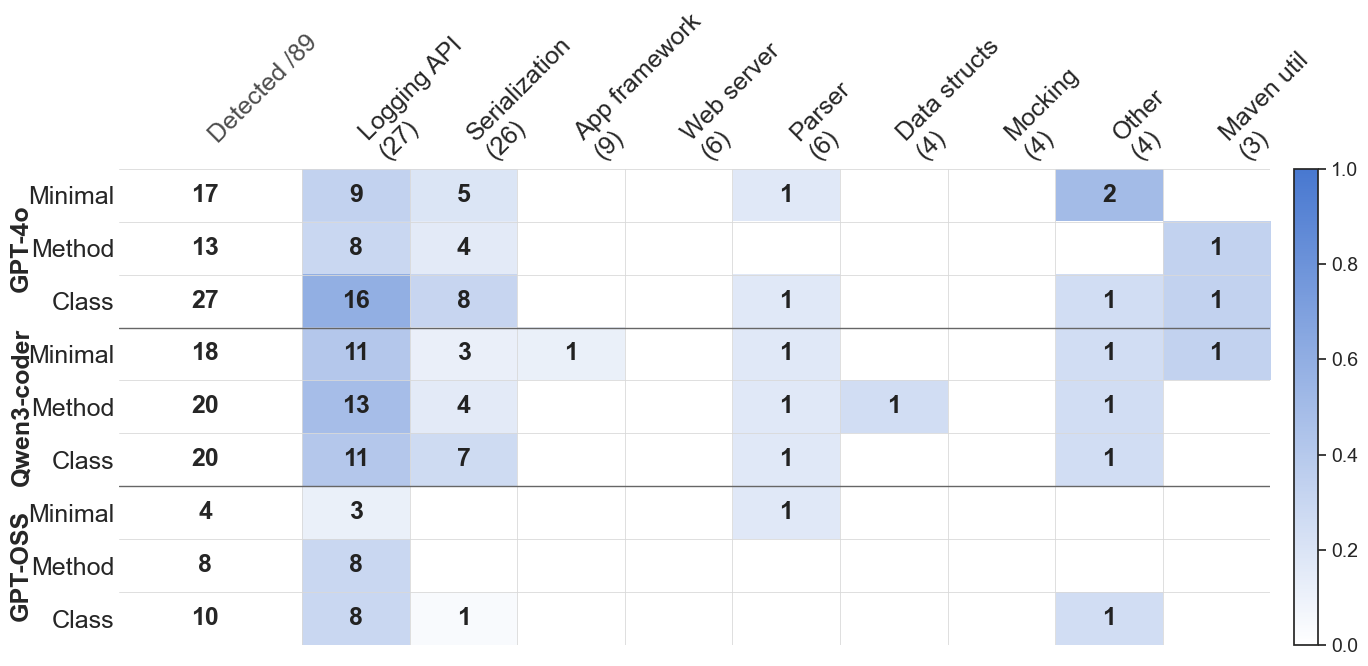

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams.update({"font.size": 18, "pdf.fonttype": 42})

categories = [
    ("Logging API", 27), ("Serialization", 26), ("App framework", 9),
    ("Web server", 6), ("Parser", 6), ("Data structs", 4),
    ("Mocking", 4), ("Other", 4), ("Maven util", 3),
]
MODEL_ORDER = ["GPT-4o", "Qwen3-coder", "GPT-OSS"]
CONTEXT_ORDER = ["Minimal", "Method", "Class"]
row_labels = [(m, c) for m in MODEL_ORDER for c in CONTEXT_ORDER]

counts = np.array([
    [ 9, 5, 0, 0, 1, 0, 0, 2, 0],
    [ 8, 4, 0, 0, 0, 0, 0, 0, 1],
    [16, 8, 0, 0, 1, 0, 0, 1, 1],
    [11, 3, 1, 0, 1, 0, 0, 1, 1],
    [13, 4, 0, 0, 1, 1, 0, 1, 0],
    [11, 7, 0, 0, 1, 0, 0, 1, 0],
    [ 3, 0, 0, 0, 1, 0, 0, 0, 0],
    [ 8, 0, 0, 0, 0, 0, 0, 0, 0],
    [ 8, 1, 0, 0, 0, 0, 0, 1, 0],
])
det_totals = [17, 13, 27, 18, 20, 20, 4, 8, 10]
N_TOTAL = 89

totals = np.array([c[1] for c in categories])
frac = counts / totals

muted_blue = sns.color_palette("muted")[0]
cmap = LinearSegmentedColormap.from_list("mutedblue", ["#ffffff", muted_blue])

n_rows, n_cols = counts.shape
fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(frac, cmap=cmap, vmin=0, vmax=1, aspect="auto")

for i in range(n_rows):
    for j in range(n_cols):
        v = counts[i, j]
        if v == 0:
            continue
        txtcol = "white" if frac[i, j] > 0.65 else "#222"
        ax.text(j, i, str(v), ha="center", va="center",
                fontsize=18, color=txtcol, fontweight="bold")

# x headers
ax.set_xticks(range(n_cols))
ax.set_xticklabels([f"{name}\n({tot})" for name, tot in categories],
                   fontsize=18, rotation=45, ha="left")
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")

# y: context only on ticks; model name once, vertical, per group
ax.set_yticks(range(n_rows))
ax.set_yticklabels([c for _, c in row_labels], fontsize=18)

model_spans = {}
for idx, (m, c) in enumerate(row_labels):
    model_spans.setdefault(m, [idx, idx])
    model_spans[m][1] = idx
for m, (s, e) in model_spans.items():
    center = (s + e) / 2
    ax.text(-0.075, center, m, transform=ax.get_yaxis_transform(),
            ha="right", va="center", fontweight="bold", fontsize=18, rotation=90)

# grid
ax.set_xticks(np.arange(-.5, n_cols, 1), minor=True)
ax.set_yticks(np.arange(-.5, n_rows, 1), minor=True)
ax.grid(which="minor", color="0.85", linewidth=0.6)
ax.tick_params(which="both", length=0)

# Det column
for i, d in enumerate(det_totals):
    ax.text(-1.4, i, f"{d}", ha="center", va="center", fontsize=18, fontweight="bold")
ax.text(-1.4, -0.9, "Detected /89", rotation=45, ha="left", va="bottom",
        fontsize=18, color="0.3")

for yy in (2.5, 5.5):
    ax.axhline(yy, color="0.4", linewidth=1.0)

ax.set_xlim(-2.2, n_cols - 0.5)

cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.ax.tick_params(labelsize=14)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig("rq2_breadth_heatmap.pdf", format="pdf", bbox_inches="tight", dpi=300)
plt.show()

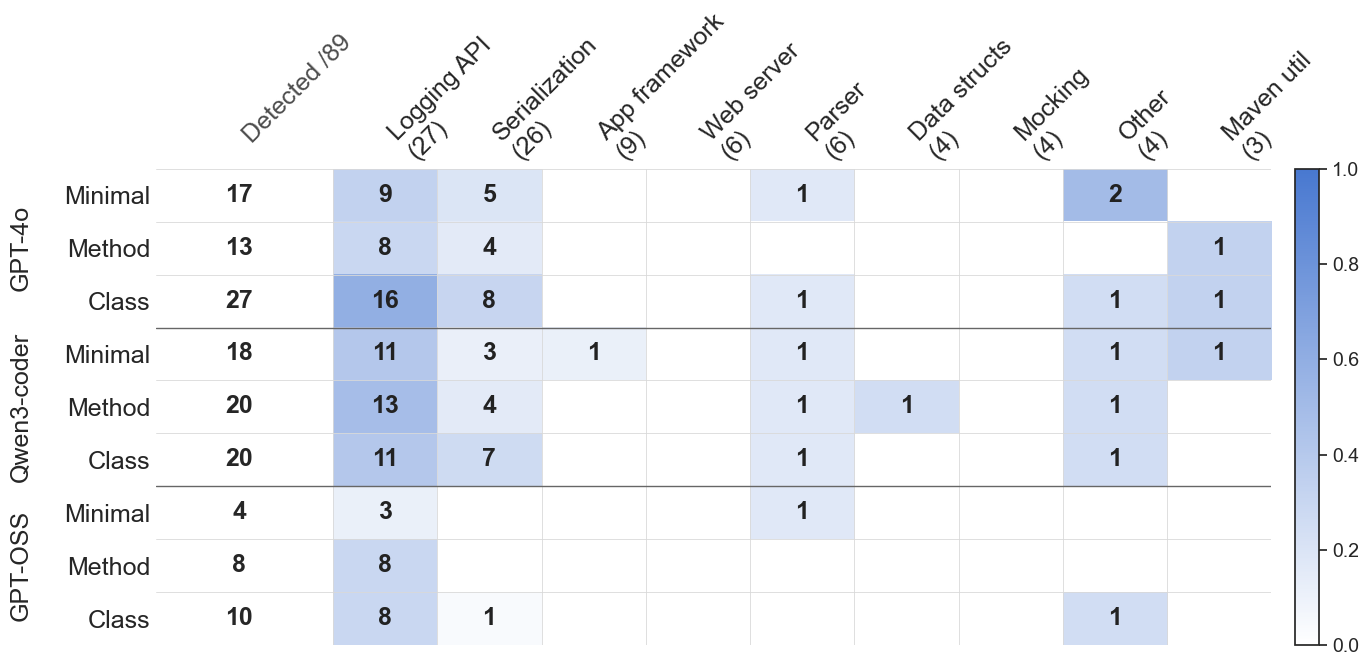

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams.update({"font.size": 18, "pdf.fonttype": 42})

categories = [
    ("Logging API", 27), ("Serialization", 26), ("App framework", 9),
    ("Web server", 6), ("Parser", 6), ("Data structs", 4),
    ("Mocking", 4), ("Other", 4), ("Maven util", 3),
]
MODEL_ORDER = ["GPT-4o", "Qwen3-coder", "GPT-OSS"]
CONTEXT_ORDER = ["Minimal", "Method", "Class"]
row_labels = [(m, c) for m in MODEL_ORDER for c in CONTEXT_ORDER]

counts = np.array([
    [ 9, 5, 0, 0, 1, 0, 0, 2, 0],
    [ 8, 4, 0, 0, 0, 0, 0, 0, 1],
    [16, 8, 0, 0, 1, 0, 0, 1, 1],
    [11, 3, 1, 0, 1, 0, 0, 1, 1],
    [13, 4, 0, 0, 1, 1, 0, 1, 0],
    [11, 7, 0, 0, 1, 0, 0, 1, 0],
    [ 3, 0, 0, 0, 1, 0, 0, 0, 0],
    [ 8, 0, 0, 0, 0, 0, 0, 0, 0],
    [ 8, 1, 0, 0, 0, 0, 0, 1, 0],
])
det_totals = [17, 13, 27, 18, 20, 20, 4, 8, 10]
N_TOTAL = 89

totals = np.array([c[1] for c in categories])
frac = counts / totals

muted_blue = sns.color_palette("muted")[0]
cmap = LinearSegmentedColormap.from_list("mutedblue", ["#ffffff", muted_blue])

n_rows, n_cols = counts.shape
fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(frac, cmap=cmap, vmin=0, vmax=1, aspect="auto")

for i in range(n_rows):
    for j in range(n_cols):
        v = counts[i, j]
        if v == 0:
            continue
        txtcol = "white" if frac[i, j] > 0.65 else "#222"
        ax.text(j, i, str(v), ha="center", va="center",
                fontsize=18, color=txtcol, fontweight="bold")

# x headers
ax.set_xticks(range(n_cols))
ax.set_xticklabels([f"{name}\n({tot})" for name, tot in categories],
                   fontsize=18, rotation=45, ha="left")
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")

# y: context only on ticks; model name once, vertical, per group
ax.set_yticks(range(n_rows))
ax.set_yticklabels([c for _, c in row_labels], fontsize=18)

model_spans = {}
for idx, (m, c) in enumerate(row_labels):
    model_spans.setdefault(m, [idx, idx])
    model_spans[m][1] = idx
for m, (s, e) in model_spans.items():
    center = (s + e) / 2
    ax.text(-0.11, center, m, transform=ax.get_yaxis_transform(),
            ha="right", va="center", fontsize=18, rotation=90)

# grid
ax.set_xticks(np.arange(-.5, n_cols, 1), minor=True)
ax.set_yticks(np.arange(-.5, n_rows, 1), minor=True)
ax.grid(which="minor", color="0.85", linewidth=0.6)
ax.tick_params(which="both", length=0)

# Det column
for i, d in enumerate(det_totals):
    ax.text(-1.4, i, f"{d}", ha="center", va="center", fontsize=18, fontweight="bold")
ax.text(-1.4, -0.9, "Detected /89", rotation=45, ha="left", va="bottom",
        fontsize=18, color="0.3")

for yy in (2.5, 5.5):
    ax.axhline(yy, color="0.4", linewidth=1.0)

ax.set_xlim(-2.2, n_cols - 0.5)

cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.ax.tick_params(labelsize=14)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.subplots_adjust(left=0.12)
plt.tight_layout()
plt.savefig("rq2_breadth_heatmap.pdf", format="pdf", bbox_inches="tight", dpi=300)
plt.show()